# PDF→Text→Chunking

In [4]:
import os, re, json, time
from pathlib import Path
from tqdm import tqdm

MODEL_NAME      = "gpt-4o-mini"
EMBEDDING_MODEL = "text-embedding-3-small"

OPENAI_API_KEY  = "your_openai_api_key_here"

NEO4J_URI       = "bolt://localhost:7687"
NEO4J_USER      = "neo4j"
NEO4J_PASSWORD  = "your_neo4j_password_here"
NEO4J_DATABASE  = "beijingkgv2"

CHUNK_SIZE      = 1200
CHUNK_OVERLAP   = 200

BASE = Path("../data/text")

PDF_FILES = [
    {
        "path": BASE / "50-climate-solutions-prc-cities.pdf",
        "city": "Chinese Cities",
        "doc_id": "prc_50solutions"
    },
    {
        "path": BASE / "city resilience plans PUBLIC/North America/WashingtonDC-US/Climate Ready DC.pdf",
        "city": "Washington DC",
        "doc_id": "dc_climate_ready"
    },
    {
        "path": BASE / "city resilience plans PUBLIC/North America/Vancouver-CA/vancouver-climate-change-adaptation-strategy-2024-25.pdf",
        "city": "Vancouver",
        "doc_id": "vancouver_adaptation_2024"
    },
    {
        "path": BASE / "city resilience plans PUBLIC/North America/Vancouver-CA/resilient-vancouver-strategy.pdf",
        "city": "Vancouver",
        "doc_id": "vancouver_resilience"
    },
    {
        "path": BASE / "city resilience plans PUBLIC/North America/Pittsburgh-US/Pittsburgh-Resilience-Strategy-English.pdf",
        "city": "Pittsburgh",
        "doc_id": "pittsburgh_resilience"
    },
    {
        "path": BASE / "city resilience plans PUBLIC/North America/Houston-US/Resilient-Houston-20200518-double-page.pdf",
        "city": "Houston",
        "doc_id": "houston_resilience"
    },
    {
        "path": BASE / "city resilience plans PUBLIC/North America/Houston-US/Huston-CAP-April2020.pdf",
        "city": "Houston",
        "doc_id": "houston_cap"
    },
    {
        "path": BASE / "city resilience plans PUBLIC/North America/Dallas-US/Dallas-2020.05.15_CECAP Report Interactive.pdf",
        "city": "Dallas",
        "doc_id": "dallas_cecap"
    },
    {
        "path": BASE / "city resilience plans PUBLIC/North America/Calgary-CA/resiliencestrategybooklet.pdf",
        "city": "Calgary",
        "doc_id": "calgary_resilience"
    },
]

# 验证
print(f"Total: {len(PDF_FILES)} PDFs\n")
for pf in PDF_FILES:
    status = "✓" if pf["path"].exists() else "✗ NOT FOUND"
    print(f"  {status}  [{pf['city']:15s}] {pf['path'].name}")

TEXT_DIR    = Path("./data/extracted_texts")
CHUNK_DIR   = Path("./data/chunks")
TRIPLET_DIR = Path("./data/triplets")

for d in [TEXT_DIR, CHUNK_DIR, TRIPLET_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Config OK. {len(PDF_FILES)} PDFs configured.")
for pf in PDF_FILES:
    exists = "✓" if pf["path"].exists() else "✗ NOT FOUND"
    print(f"  {exists}  [{pf['city']}] {pf['path'].name}")

Total: 9 PDFs

  ✓  [Chinese Cities ] 50-climate-solutions-prc-cities.pdf
  ✓  [Washington DC  ] Climate Ready DC.pdf
  ✓  [Vancouver      ] vancouver-climate-change-adaptation-strategy-2024-25.pdf
  ✓  [Vancouver      ] resilient-vancouver-strategy.pdf
  ✓  [Pittsburgh     ] Pittsburgh-Resilience-Strategy-English.pdf
  ✓  [Houston        ] Resilient-Houston-20200518-double-page.pdf
  ✓  [Houston        ] Huston-CAP-April2020.pdf
  ✓  [Dallas         ] Dallas-2020.05.15_CECAP Report Interactive.pdf
  ✓  [Calgary        ] resiliencestrategybooklet.pdf
Config OK. 9 PDFs configured.
  ✓  [Chinese Cities] 50-climate-solutions-prc-cities.pdf
  ✓  [Washington DC] Climate Ready DC.pdf
  ✓  [Vancouver] vancouver-climate-change-adaptation-strategy-2024-25.pdf
  ✓  [Vancouver] resilient-vancouver-strategy.pdf
  ✓  [Pittsburgh] Pittsburgh-Resilience-Strategy-English.pdf
  ✓  [Houston] Resilient-Houston-20200518-double-page.pdf
  ✓  [Houston] Huston-CAP-April2020.pdf
  ✓  [Dallas] Dallas-2020.05.1

In [ ]:
import fitz 

PAGE_NUM_PATTERNS = [
    r'^\s*\d{1,3}\s*$',                  
    r'^\s*[-–—]\s*\d{1,3}\s*[-–—]\s*$',         
    r'^\s*[Pp]age\s+\d+\s*(of\s+\d+)?\s*$',      
    r'^\s*\d+\s*/\s*\d+\s*$',                    
]

HEADER_FOOTER_PATTERNS = [
    r'(?i)climate\s+ready\s+dc',
    r'(?i)resilient\s+(houston|vancouver|pittsburgh|dallas|calgary)',
    r'(?i)resilience\s+strategy',
    r'(?i)^\s*(chapter|section)\s+\d+',
    r'(?i)www\.',                          
    r'(?i)©\s*\d{4}',                       
    r'(?i)all\s+rights\s+reserved',
    r'(?i)^\s*table\s+of\s+contents?\s*$',
    r'(?i)^\s*contents?\s*$',
]

TOC_PATTERN = re.compile(r'^.{5,80}\.{4,}\s*\d{1,3}\s*$')

MIN_LINE_CHARS = 8

def is_noise_line(line: str) -> bool:
    stripped = line.strip()
    if not stripped:
        return False 

    for pat in PAGE_NUM_PATTERNS:
        if re.match(pat, stripped):
            return True

    for pat in HEADER_FOOTER_PATTERNS:
        if re.search(pat, stripped):
            return True

    if TOC_PATTERN.match(stripped):
        return True

    return False


def clean_page_text(text: str, page_num: int, total_pages: int) -> str:
    lines = text.split('\n')

    header_candidates = lines[:2]
    footer_candidates = lines[-2:]
    body_lines = lines[2:-2] if len(lines) > 4 else lines

    cleaned = []
    for i, line in enumerate(lines):
        if i < 2 or i >= len(lines) - 2:
            if is_noise_line(line) or (len(line.strip()) < MIN_LINE_CHARS and line.strip()):
                continue 
        else:
            if is_noise_line(line):
                continue
        cleaned.append(line)

    text = '\n'.join(cleaned)

    text = re.sub(r'(\w)-\n(\w)', r'\1\2', text)

    text = re.sub(r'(?<![.!?:])\n(?![A-Z\n•\-\*\d])', ' ', text)

    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)

    text = re.sub(r'^\s*[■□▪▸►●○◆◇→←↑↓\-=_*]{3,}\s*$', '', text, flags=re.MULTILINE)

    return text.strip()


def is_toc_page(page_text: str) -> bool:
    lines = [l for l in page_text.split('\n') if l.strip()]
    if not lines:
        return False
    toc_lines = sum(1 for l in lines if TOC_PATTERN.match(l.strip()))
    return toc_lines / len(lines) > 0.4


def is_mostly_empty(page_text: str, threshold: int = 50) -> bool:
    return len(page_text.strip()) < threshold


def pdf_to_text(pdf_info: dict, out_dir: Path) -> Path:
    pdf_path = pdf_info["path"]
    city     = pdf_info["city"]
    doc_id   = pdf_info["doc_id"]

    doc = fitz.open(str(pdf_path))
    total_pages = len(doc)
    extracted_pages = []
    skipped = {"toc": 0, "empty": 0}

    for page_num in range(total_pages):
        page = doc[page_num]

        text = page.get_text("text")

        if is_mostly_empty(text):
            skipped["empty"] += 1
            continue

        if is_toc_page(text):
            skipped["toc"] += 1
            continue

        cleaned = clean_page_text(text, page_num + 1, total_pages)

        if cleaned:
            extracted_pages.append({
                "page_num": page_num + 1,
                "text": cleaned
            })

    full_text = "\n\n".join(
        f"[Page {p['page_num']}]\n{p['text']}"
        for p in extracted_pages
    )

    out_path = out_dir / f"{doc_id}.txt"
    out_path.write_text(full_text, encoding="utf-8")

    print(f"  ✓ {pdf_path.name}")
    print(f"    City: {city} | Pages: {total_pages} total, "
          f"{len(extracted_pages)} extracted, "
          f"{skipped['toc']} TOC skipped, "
          f"{skipped['empty']} empty skipped")
    print(f"    Output: {len(full_text):,} chars → {out_path.name}")

    return out_path


print("Extracting PDFs...\n")
text_files = []
for pdf_info in PDF_FILES:
    if not pdf_info["path"].exists():
        print(f"  ✗ SKIPPED (file not found): {pdf_info['path']}")
        continue
    tf = pdf_to_text(pdf_info, TEXT_DIR)
    text_files.append({**pdf_info, "text_path": tf})

print(f"\nDone. {len(text_files)} files extracted.")

Extracting PDFs...

  ✓ 50-climate-solutions-prc-cities.pdf
    City: Chinese Cities | Pages: 78 total, 77 extracted, 0 TOC skipped, 1 empty skipped
    Output: 155,635 chars → prc_50solutions.txt
  ✓ Climate Ready DC.pdf
    City: Washington DC | Pages: 46 total, 39 extracted, 0 TOC skipped, 7 empty skipped
    Output: 105,934 chars → dc_climate_ready.txt
  ✓ vancouver-climate-change-adaptation-strategy-2024-25.pdf
    City: Vancouver | Pages: 72 total, 71 extracted, 1 TOC skipped, 0 empty skipped
    Output: 186,261 chars → vancouver_adaptation_2024.txt
  ✓ resilient-vancouver-strategy.pdf
    City: Vancouver | Pages: 98 total, 82 extracted, 0 TOC skipped, 16 empty skipped
    Output: 147,053 chars → vancouver_resilience.txt
  ✓ Pittsburgh-Resilience-Strategy-English.pdf
    City: Pittsburgh | Pages: 61 total, 59 extracted, 1 TOC skipped, 0 empty skipped
    Output: 204,921 chars → pittsburgh_resilience.txt
  ✓ Resilient-Houston-20200518-double-page.pdf
    City: Houston | Pages: 94 

In [6]:
# check text-clean
import random

print("=" * 70)
print("QUALITY CHECK — random samples from extracted texts")
print("=" * 70)

for tf in text_files[:3]: 
    text = tf["text_path"].read_text(encoding="utf-8")
    lines = [l for l in text.split('\n') if l.strip()]
    total_chars = len(text)
    total_lines = len(lines)

    print(f"\n{'─'*60}")
    print(f"[{tf['city']}] {tf['doc_id']}")
    print(f"Total: {total_chars:,} chars, {total_lines:,} non-empty lines")
    print(f"\nFirst 500 chars:")
    print(text[:500])
    print(f"\nRandom 300 chars from middle:")
    mid = len(text) // 2
    print(text[mid:mid+300])

QUALITY CHECK — random samples from extracted texts

────────────────────────────────────────────────────────────
[Chinese Cities] prc_50solutions
Total: 155,635 chars, 2,045 non-empty lines

First 500 chars:
[Page 1]
ASIAN DEVELOPMENT BANK
50 CLIMATE SOLUTIONS 
FROM CITIES IN THE 
PEOPLE’S REPUBLIC OF CHINA
Best Practices from Cities Taking Action on Climate Change
NOVEMBER 2018

[Page 3]
ASIAN DEVELOPMENT BANK
50 CLIMATE SOLUTIONS 
FROM CITIES IN THE 
PEOPLE’S REPUBLIC OF CHINA
Best Practices from Cities Taking Action on Climate Change
NOVEMBER 2018

[Page 4]
Creative Commons Attribution 3.0 IGO license (CC BY 3.0 IGO)
6 ADB Avenue, Mandaluyong City, 1550 Metro Manila, Philippines
Tel +63 2 632 444

Random 300 chars from middle:
ually. Environment
More eﬃcient fuel and resource use, enabled through the cloud platform, reduces CO2 and particulate emissions in the already polluted city of Wuhai. Social
The project supports more than 
1,200 jobs, and substantially improves the working c

In [7]:
# chunking
from langchain.text_splitter import RecursiveCharacterTextSplitter
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")

def count_tokens(text: str) -> int:
    return len(enc.encode(text))

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=count_tokens,
    separators=["\n\n", "\n", ". ", " ", ""]
)

all_chunks = []

for tf in text_files:
    city   = tf["city"]
    doc_id = tf["doc_id"]
    raw = tf["text_path"].read_text(encoding="utf-8")
    lines = raw.split('\n')
    cleaned_lines = []
    for line in lines:
        s = line.strip()
        if re.match(r'^\[Page \d+\]$', s):
            continue
        if re.search(r'https?://|www\.|\.gov/|\.org/|\.com/', s) and len(s) < 150:
            continue
        if re.match(r'^\d{1,2}\.\s+\w', s) and len(s) < 150 and (':' in s or re.search(r'\d{4}', s)):
            continue
        if 0 < len(s.split()) <= 2:
            continue
        cleaned_lines.append(line)
    
    raw = re.sub(r'\n{3,}', '\n\n', '\n'.join(cleaned_lines)).strip()

    chunks = splitter.split_text(raw)

    valid_chunks = []
    for c in chunks:
        if count_tokens(c) < 80:
            continue
        alpha_ratio = sum(1 for ch in c if ch.isalpha()) / max(len(c), 1)
        if alpha_ratio < 0.45:
            continue
        valid_chunks.append(c)

    for i, chunk in enumerate(valid_chunks):
        all_chunks.append({
            "city":         city,
            "doc_id":       doc_id,
            "source":       tf["path"].name,
            "chunk_id":     f"{doc_id}_chunk_{i:04d}",
            "chunk_idx":    i,
            "total_chunks": len(valid_chunks),
            "text":         chunk,
            "token_count":  count_tokens(chunk)
        })

    avg_tok = sum(count_tokens(c) for c in valid_chunks) // max(len(valid_chunks), 1)
    print(f"  [{city:15s}] {doc_id}: {len(chunks)} raw → {len(valid_chunks)} valid chunks (avg {avg_tok} tokens)")

print(f"\nTotal chunks: {len(all_chunks)}")
print("\nBy city:")
from collections import Counter
for city, cnt in Counter(c["city"] for c in all_chunks).most_common():
    print(f"  {city:20s}: {cnt} chunks")

chunks_path = CHUNK_DIR / "all_chunks.json"
with open(chunks_path, 'w', encoding='utf-8') as f:
    json.dump(all_chunks, f, ensure_ascii=False, indent=2)
print(f"\nSaved {chunks_path}")

  [Chinese Cities ] prc_50solutions: 33 raw → 33 valid chunks (avg 984 tokens)
  [Washington DC  ] dc_climate_ready: 20 raw → 20 valid chunks (avg 964 tokens)
  [Vancouver      ] vancouver_adaptation_2024: 42 raw → 42 valid chunks (avg 846 tokens)
  [Vancouver      ] vancouver_resilience: 31 raw → 31 valid chunks (avg 908 tokens)
  [Pittsburgh     ] pittsburgh_resilience: 44 raw → 44 valid chunks (avg 873 tokens)
  [Houston        ] houston_resilience: 106 raw → 106 valid chunks (avg 834 tokens)
  [Houston        ] houston_cap: 38 raw → 38 valid chunks (avg 939 tokens)
  [Dallas         ] dallas_cecap: 80 raw → 78 valid chunks (avg 861 tokens)
  [Calgary        ] calgary_resilience: 64 raw → 63 valid chunks (avg 921 tokens)

Total chunks: 455

By city:
  Houston             : 144 chunks
  Dallas              : 78 chunks
  Vancouver           : 73 chunks
  Calgary             : 63 chunks
  Pittsburgh          : 44 chunks
  Chinese Cities      : 33 chunks
  Washington DC       : 20 chunk

In [8]:
# validation chunking
import random

print("=" * 65)
print("CHUNK QUALITY CHECK")
print("=" * 65)

seen_cities = set()
samples = []
for c in all_chunks:
    if c["city"] not in seen_cities:
        samples.append(c)
        seen_cities.add(c["city"])

for s in samples:
    print(f"\n{'─'*60}")
    print(f"[{s['city']}] {s['doc_id']} | chunk {s['chunk_idx']} | {s['token_count']} tokens")
    print(s['text'][:400])
    print("...")

CHUNK QUALITY CHECK

────────────────────────────────────────────────────────────
[Chinese Cities] prc_50solutions | chunk 0 | 1044 tokens
ASIAN DEVELOPMENT BANK
50 CLIMATE SOLUTIONS 
FROM CITIES IN THE 
PEOPLE’S REPUBLIC OF CHINA
Best Practices from Cities Taking Action on Climate Change

ASIAN DEVELOPMENT BANK
50 CLIMATE SOLUTIONS 
FROM CITIES IN THE 
PEOPLE’S REPUBLIC OF CHINA
Best Practices from Cities Taking Action on Climate Change

Creative Commons Attribution 3.0 IGO license (CC BY 3.0 IGO)
6 ADB Avenue, Mandaluyong City, 155
...

────────────────────────────────────────────────────────────
[Washington DC] dc_climate_ready | chunk 0 | 1004 tokens
climate resilient by 2050:
MAKING PROGRESS TOWARD

FOREWORD letter from mayor muriel bowser address our vulnerabilities and proactively ensure those who are most economically and physically at risk do not disproportionately shoulder the burden. 
The District has already taken steps to build a culture of resilience in which agencies col

# Triple Extraction

In [9]:

ONTOLOGY = {
    "node_types": [
        # ── UrbanSystem ───────────────────────────────────────
        {"label": "City",             "props": ["name", "administrative_level", "climate_zone", "population", "gdp_per_capita", "region", "is_case_study"]},
        {"label": "UrbanZone",        "props": ["zone_type", "area_km2", "population_density", "land_use_type"]},
        {"label": "Infrastructure",   "props": ["infra_type", "infra_color", "capacity", "condition", "service_coverage"]},
        {"label": "ExposureUnit",     "props": ["population_count", "asset_value", "vulnerable_ratio", "social_capital_index"]},
        # ── ClimateRisk ───────────────────────────────────────
        {"label": "ClimateHazard",    "props": ["hazard_type", "frequency", "severity", "trend", "return_period", "spatial_extent"]},
        {"label": "Vulnerability",    "props": ["vuln_type", "exposure_score", "sensitivity_score", "adaptive_capacity_score", "affected_group"]},
        # ── Governance ────────────────────────────────────────
        {"label": "Actor",            "props": ["name", "sector", "role", "authority_level", "resources", "is_bridge_organization"]},
        {"label": "Policy",           "props": ["policy_name", "policy_type", "level", "year_issued", "year_expired", "legal_binding"]},
        {"label": "Mechanism",        "props": ["mechanism_type", "source_of_funding", "legal_basis", "scale_usd"]},
        {"label": "Constraint",       "props": ["constraint_type", "severity_score", "affected_stakeholder", "is_structural"]},
        # ── Intervention ──────────────────────────────────────
        {"label": "AdaptationAction", "props": ["action_name", "status", "spatial_scale", "adaptation_type", "start_year", "end_year", "cost_usd", "co_benefits"]},
        # ── Evaluation ────────────────────────────────────────
        {"label": "Outcome",          "props": ["outcome_type", "indicator", "value", "unit", "is_co_benefit", "evidence_quality"]},
        {"label": "Indicator",        "props": ["indicator_name", "unit", "baseline", "target", "data_source"]},
        {"label": "ResilienceState",  "props": ["resilience_type", "measurement", "recovery_time", "absorption_capacity", "transformation_capacity"]},
        {"label": "TimePoint",        "props": ["year", "period", "policy_cycle"]},
    ],
    "relation_types": [
        # ── Urban Structure ───────────────────────────────────
        {"type": "HAS_ZONE",           "from": "City",             "to": "UrbanZone",        "rel_props": []},
        {"type": "HAS_INFRASTRUCTURE", "from": "UrbanZone",        "to": "Infrastructure",   "rel_props": []},
        {"type": "SERVES",             "from": "Infrastructure",   "to": "ExposureUnit",     "rel_props": ["service_level"]},
        # ── Risk Chain ────────────────────────────────────────
        {"type": "EXPERIENCES",        "from": "City",             "to": "ClimateHazard",    "rel_props": []},
        {"type": "AFFECTS_ZONE",       "from": "ClimateHazard",    "to": "UrbanZone",        "rel_props": ["impact_severity"]},
        {"type": "EXPOSES",            "from": "ClimateHazard",    "to": "ExposureUnit",     "rel_props": []},
        {"type": "WORSENS",            "from": "ClimateHazard",    "to": "Vulnerability",    "rel_props": []},
        {"type": "EXPERIENCES_VULN",   "from": "ExposureUnit",     "to": "Vulnerability",    "rel_props": []},
        # ── Governance ────────────────────────────────────────
        {"type": "ISSUED_BY",          "from": "Policy",           "to": "Actor",            "rel_props": []},
        {"type": "MANDATES",           "from": "Policy",           "to": "AdaptationAction", "rel_props": []},
        {"type": "IMPLEMENTS",         "from": "Actor",            "to": "AdaptationAction", "rel_props": []},
        {"type": "PARTICIPATES_IN",    "from": "Actor",            "to": "AdaptationAction", "rel_props": []},
        {"type": "COORDINATES_WITH",   "from": "Actor",            "to": "Actor",            "rel_props": []},
        {"type": "REPORTS_TO",         "from": "Actor",            "to": "Actor",            "rel_props": []},
        {"type": "MANAGES",            "from": "Actor",            "to": "Mechanism",        "rel_props": []},
        {"type": "FACES",              "from": "Actor",            "to": "Constraint",       "rel_props": []},
        # ── Core Causal Chain ─────────────────────────────────
        {"type": "LOCATED_IN",         "from": "AdaptationAction", "to": "City",             "rel_props": []},
        {"type": "TARGETS_ZONE",       "from": "AdaptationAction", "to": "UrbanZone",        "rel_props": []},
        {"type": "ADDRESSES",          "from": "AdaptationAction", "to": "ClimateHazard",    "rel_props": []},
        {"type": "REDUCES",            "from": "AdaptationAction", "to": "Vulnerability",    "rel_props": []},
        {"type": "IMPROVES",           "from": "AdaptationAction", "to": "Infrastructure",   "rel_props": []},
        {"type": "FACILITATED_BY",     "from": "AdaptationAction", "to": "Mechanism",        "rel_props": []},
        {"type": "HINDERED_BY",        "from": "AdaptationAction", "to": "Constraint",       "rel_props": []},
        {"type": "PRODUCES",           "from": "AdaptationAction", "to": "Outcome",          "rel_props": []},
        # ── Evaluation ────────────────────────────────────────
        {"type": "MEASURES",           "from": "Indicator",        "to": "Outcome",          "rel_props": []},
        {"type": "MONITORS",           "from": "Actor",            "to": "Indicator",        "rel_props": []},
        {"type": "REFLECTS",           "from": "Outcome",          "to": "ResilienceState",  "rel_props": []},
        # ── Temporal ──────────────────────────────────────────
        {"type": "STARTED_AT",         "from": "AdaptationAction", "to": "TimePoint",        "rel_props": []},
        {"type": "ISSUED_AT",          "from": "Policy",           "to": "TimePoint",        "rel_props": []},
        {"type": "RECORDED_AT",        "from": "Indicator",        "to": "TimePoint",        "rel_props": ["value"]},
    ]
}

node_labels      = [n["label"] for n in ONTOLOGY["node_types"]]
relation_types   = [r["type"]  for r in ONTOLOGY["relation_types"]]
REL_DOMAIN_RANGE = {r["type"]: (r["from"], r["to"]) for r in ONTOLOGY["relation_types"]}
REL_PROPS        = {r["type"]: r["rel_props"] for r in ONTOLOGY["relation_types"]}

NODE_PRIMARY_KEY = {
    "City":             "name",
    "UrbanZone":        "name",
    "Infrastructure":   "name",
    "ExposureUnit":     "name",
    "ClimateHazard":    "name",
    "Vulnerability":    "name",
    "Actor":            "name",
    "Policy":           "policy_name",
    "Mechanism":        "name",
    "Constraint":       "name",
    "AdaptationAction": "action_name",
    "Outcome":          "name",
    "Indicator":        "indicator_name",
    "ResilienceState":  "name",
    "TimePoint":        "year",
}

NODE_ALLOWED_PROPS = {n["label"]: n["props"] for n in ONTOLOGY["node_types"]}

ONTOLOGY_NODE_STR = "\n".join(
    f"  {n['label']:20s} props: {n['props']}"
    for n in ONTOLOGY["node_types"]
)

ONTOLOGY_REL_STR = "\n".join(
    f"  {r['type']:25s} ({r['from']} → {r['to']})"
    + (f"  [rel_props: {r['rel_props']}]" if r["rel_props"] else "")
    for r in ONTOLOGY["relation_types"]
)

print(f"Node types    : {len(node_labels)}")
print(f"Relation types: {len(relation_types)}")
print(f"\nNode labels: {node_labels}")
print(f"\nRelation types: {relation_types}")

Node types    : 15
Relation types: 30

Node labels: ['City', 'UrbanZone', 'Infrastructure', 'ExposureUnit', 'ClimateHazard', 'Vulnerability', 'Actor', 'Policy', 'Mechanism', 'Constraint', 'AdaptationAction', 'Outcome', 'Indicator', 'ResilienceState', 'TimePoint']

Relation types: ['HAS_ZONE', 'HAS_INFRASTRUCTURE', 'SERVES', 'EXPERIENCES', 'AFFECTS_ZONE', 'EXPOSES', 'WORSENS', 'EXPERIENCES_VULN', 'ISSUED_BY', 'MANDATES', 'IMPLEMENTS', 'PARTICIPATES_IN', 'COORDINATES_WITH', 'REPORTS_TO', 'MANAGES', 'FACES', 'LOCATED_IN', 'TARGETS_ZONE', 'ADDRESSES', 'REDUCES', 'IMPROVES', 'FACILITATED_BY', 'HINDERED_BY', 'PRODUCES', 'MEASURES', 'MONITORS', 'REFLECTS', 'STARTED_AT', 'ISSUED_AT', 'RECORDED_AT']


In [10]:
from openai import OpenAI

client = OpenAI(api_key=OPENAI_API_KEY)

SYSTEM_PROMPT = f"""You are a knowledge graph extraction specialist for urban climate adaptation research.

Your task is to extract structured triplets from policy documents written by city governments.

## DOMAIN FOCUS
Urban climate adaptation: how cities identify climate hazards, design and implement adaptation actions, 
govern those actions through policies and institutions, overcome constraints, and evaluate outcomes.
Prioritize extracting:
- CAUSAL CHAINS: hazard → vulnerability → adaptation action → outcome
- GOVERNANCE STRUCTURES: who mandates, implements, funds, or constrains what
- SPECIFIC INTERVENTIONS: named programs, projects, policies with concrete details
- MEASURABLE OUTCOMES: quantified targets, indicators, timelines

## ONTOLOGY

### Node Types (use ONLY these labels):
{ONTOLOGY_NODE_STR}

### Relation Types (use ONLY these, respect domain → range strictly):
{ONTOLOGY_REL_STR}

## EXTRACTION RULES
1. STRICT ONTOLOGY COMPLIANCE: only use node labels and relation types listed above.
   The subject_type must match the relation's domain, object_type must match the range.
2. SPECIFICITY OVER GENERALITY: extract named, specific entities (e.g. "Green Infrastructure 
   Fund" not "funding"; "Urban Heat Island" not "climate issue"). Skip generic statements 
   that could apply to any city.
3. NODE PROPERTIES: populate as many fields as the text supports. Use null for unknown fields.
4. CAUSAL PREFERENCE: prioritize triplets that express cause-effect, mandate, implementation, 
   or constraint relationships over simple co-occurrence.
5. EVIDENCE REQUIRED: every triplet must be directly supported by the text. 
   Quote ≤15 words as evidence.
6. CONFIDENCE LEVELS:
   - HIGH: explicitly stated in text
   - MEDIUM: clearly implied by context
   - LOW: reasonably inferred but not directly stated
7. RELATION PROPERTIES: if a relation has rel_props (e.g. service_level, impact_severity, value),
   include them when mentioned in text.
8. AVOID: generic facts ("cities face climate change"), tautologies, or triplets not 
   grounded in this specific document.

## OUTPUT FORMAT
Return ONLY a JSON object with key "triplets". No explanation, no markdown.

{{
  "triplets": [
    {{
      "subject":        "Specific Entity Name",
      "subject_type":   "NodeLabel",
      "subject_props":  {{"prop": "value"}},
      "relation":       "RELATION_TYPE",
      "rel_properties": {{}},
      "object":         "Specific Entity Name",
      "object_type":    "NodeLabel",
      "object_props":   {{"prop": "value"}},
      "confidence":     "HIGH|MEDIUM|LOW",
      "evidence":       "direct quote from text ≤15 words"
    }}
  ]
}}
"""

def extract_triplets(chunk: dict, max_retries: int = 3) -> list:
    user_msg = f"""DOCUMENT CONTEXT
City: {chunk['city']}
Document: {chunk['source']}
Position: chunk {chunk['chunk_idx'] + 1} of {chunk['total_chunks']}

TEXT TO EXTRACT FROM:
{chunk['text']}
"""
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=MODEL_NAME,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": user_msg}
                ],
                temperature=0.0,
                max_tokens=2000,
                response_format={"type": "json_object"}
            )
            raw      = response.choices[0].message.content
            parsed   = json.loads(raw)
            triplets = parsed.get("triplets", [])
            if isinstance(triplets, dict):
                triplets = list(triplets.values())[0]
            for t in triplets:
                t["city"]     = chunk["city"]
                t["chunk_id"] = chunk["chunk_id"]
                t["source"]   = chunk["source"]
            return triplets
        except Exception as e:
            print(f"    Attempt {attempt+1} failed: {e}")
            time.sleep(2 ** attempt)
    return []


all_triplets  = []
failed_chunks = []

print(f"Starting extraction: {len(all_chunks)} chunks with {MODEL_NAME}\n")

for chunk in tqdm(all_chunks, desc="Extracting"):
    triplets = extract_triplets(chunk)
    if triplets:
        all_triplets.extend(triplets)
    else:
        failed_chunks.append(chunk["chunk_id"])
    time.sleep(0.3)

print(f"\nExtracted : {len(all_triplets)} raw triplets")
print(f"Failed    : {len(failed_chunks)} chunks")

raw_path = TRIPLET_DIR / "triplets_raw.json"
with open(raw_path, 'w', encoding='utf-8') as f:
    json.dump(all_triplets, f, ensure_ascii=False, indent=2)
print(f"Saved     → {raw_path}")

Starting extraction: 455 chunks with gpt-4o-mini



Extracting:   9%|▊         | 39/455 [15:47<2:55:10, 25.27s/it]

    Attempt 1 failed: Unterminated string starting at: line 268 column 24 (char 8148)
    Attempt 2 failed: Unterminated string starting at: line 268 column 24 (char 8136)


Extracting:  20%|█▉        | 90/455 [36:25<2:09:05, 21.22s/it]

    Attempt 1 failed: Expecting ',' delimiter: line 123 column 2 (char 7573)
    Attempt 2 failed: Unterminated string starting at: line 121 column 25 (char 7510)


...

    Attempt 1 failed: Expecting property name enclosed in double quotes: line 284 column 6 (char 8089)
    Attempt 2 failed: Unterminated string starting at: line 279 column 9 (char 8141)
    Attempt 3 failed: Expecting property name enclosed in double quotes: line 280 column 1 (char 8151)


Extracting:  84%|████████▍ | 383/455 [2:21:11<25:53, 21.58s/it]  

    Attempt 1 failed: Unterminated string starting at: line 250 column 9 (char 8408)
    Attempt 2 failed: Unterminated string starting at: line 252 column 9 (char 8440)
    Attempt 3 failed: Expecting value: line 252 column 22 (char 8408)


Extracting: 100%|██████████| 455/455 [2:44:52<00:00, 21.74s/it]


Extracted : 2122 raw triplets
Failed    : 35 chunks
Saved     → data/triplets/triplets_raw.json


In [11]:
# validation
import pandas as pd

with open(TRIPLET_DIR / "triplets_raw.json", encoding="utf-8") as f:
    all_triplets = json.load(f)

df = pd.DataFrame(all_triplets)
print(f"Raw: {len(df)} triplets\n")

def is_valid(row) -> bool:
    s_type = row.get("subject_type", "")
    o_type = row.get("object_type",  "")
    rel    = row.get("relation",     "")
    if s_type not in node_labels:    return False
    if o_type not in node_labels:    return False
    if rel    not in relation_types: return False
    exp_from, exp_to = REL_DOMAIN_RANGE[rel]
    if s_type != exp_from: return False
    if o_type != exp_to:   return False
    return True

df["valid"] = df.apply(is_valid, axis=1)
invalid = df[~df["valid"]]
print(f"Ontology violations : {len(invalid)}")
if len(invalid) > 0:
    print("Top violation patterns:")
    print(invalid.groupby(["subject_type", "relation", "object_type"]).size()
          .sort_values(ascending=False).head(10).to_string())

df_valid = df[df["valid"]].copy()

def normalize(name: str) -> str:
    return re.sub(r'\s+', ' ', str(name)).strip().title()

df_valid["subject"] = df_valid["subject"].apply(normalize)
df_valid["object"]  = df_valid["object"].apply(normalize)

df_valid = df_valid[
    (df_valid["subject"].str.len() > 2) &
    (df_valid["object"].str.len()  > 2)
]

df_dedup = df_valid.drop_duplicates(
    subset=["subject", "relation", "object"], keep="first"
).reset_index(drop=True)

print(f"After validation    : {len(df_valid)}")
print(f"After dedup         : {len(df_dedup)}")

print(f"\nBy city:\n{df_dedup['city'].value_counts().to_string()}")
print(f"\nTop relations:\n{df_dedup['relation'].value_counts().head(12).to_string()}")
print(f"\nNode type distribution (subject):\n{df_dedup['subject_type'].value_counts().to_string()}")

clean_path = TRIPLET_DIR / "triplets_clean.json"
df_dedup.to_json(clean_path, orient="records", force_ascii=False, indent=2)
print(f"\nSaved → {clean_path}")

Raw: 2122 triplets

Ontology violations : 1143
Top violation patterns:
subject_type  relation          object_type     
City          MANDATES          AdaptationAction    300
              PRODUCES          Outcome              68
              COORDINATES_WITH  Actor                61
              MANDATES          Policy               55
Actor         MANDATES          AdaptationAction     50
City          PARTICIPATES_IN   AdaptationAction     38
              EXPERIENCES_VULN  Vulnerability        25
              PARTICIPATES_IN   Actor                25
              WORSENS           Vulnerability        22
              TARGETS_ZONE      UrbanZone            20
After validation    : 979
After dedup         : 864

By city:
city
Houston           243
Vancouver         151
Dallas            134
Calgary           110
Chinese Cities     89
Pittsburgh         71
Washington DC      66

Top relations:
relation
PRODUCES            211
EXPERIENCES         194
LOCATED_IN          135
MA

# Neo4j

In [14]:
NEO4J_DATABASE = "kgv3"


In [15]:
from neo4j import GraphDatabase

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

def verify(tx):
    tx.run("CREATE (t:_Test {ts: timestamp()}) DELETE t")

try:
    with driver.session(database="kgv3") as session:
        session.execute_write(verify)
    print("Write permissions are normal")
except Exception as e:
    print(f"Write failed: {e}")
finally:
    driver.close()

Write permissions are normal


In [16]:
from neo4j import GraphDatabase

class Neo4jKG:
    def __init__(self, uri, user, password, database):
        self.driver   = GraphDatabase.driver(uri, auth=(user, password))
        self.database = database

    def close(self):
        self.driver.close()

    def run(self, query, parameters=None):
        with self.driver.session(database=self.database) as session:
            return [dict(r) for r in session.run(query, parameters or {})]

    def run_write(self, query, parameters=None):
        with self.driver.session(database=self.database) as session:
            return session.execute_write(
                lambda tx: list(tx.run(query, parameters or {}))
            )

kg = Neo4jKG(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, "kgv3")
print("Connected to kgv3")

Connected to kgv3


In [17]:
CONSTRAINTS = [
    ("City",             "name"),
    ("UrbanZone",        "name"),
    ("Infrastructure",   "name"),
    ("ExposureUnit",     "name"),
    ("ClimateHazard",    "name"),
    ("Vulnerability",    "name"),
    ("Actor",            "name"),
    ("Policy",           "policy_name"),  
    ("Mechanism",        "name"),
    ("Constraint",       "name"),
    ("AdaptationAction", "action_name"),  
    ("Outcome",          "name"),
    ("Indicator",        "indicator_name"), 
    ("ResilienceState",  "name"),
    ("TimePoint",        "year"),        
]


for label, prop in CONSTRAINTS:
    try:
        kg.run_write(f"""
            CREATE CONSTRAINT {label.lower()}_{prop}_unique IF NOT EXISTS
            FOR (n:{label}) REQUIRE n.{prop} IS UNIQUE
        """)
        print(f"  {label}.{prop}")
    except Exception as e:
        print(f"  {label}: {e}")

try:
    kg.run_write("""
        CREATE VECTOR INDEX node_embedding IF NOT EXISTS
        FOR (n:AdaptationAction)
        ON n.embedding
        OPTIONS {indexConfig: {
            `vector.dimensions`: 1536,
            `vector.similarity_function`: 'cosine'
        }}
    """)
    print("  Vector index")
except Exception as e:
    print(f"  Vector index: {e}")

print("\nSchema done.")

  City.name
  UrbanZone.name
  Infrastructure.name
  ExposureUnit.name
  ClimateHazard.name
  Vulnerability.name
  Actor.name
  Policy.policy_name
  Mechanism.name
  Constraint.name
  AdaptationAction.action_name
  Outcome.name
  Indicator.indicator_name
  ResilienceState.name
  TimePoint.year
  Vector index

Schema done.


In [18]:
with open(TRIPLET_DIR / "triplets_clean.json", encoding="utf-8") as f:
    triplets = json.load(f)

print(f"Writing {len(triplets)} triplets to kgv3...\n")

NODE_PRIMARY_KEY = {
    "City":             "name",
    "UrbanZone":        "name",
    "Infrastructure":   "name",
    "ExposureUnit":     "name",
    "ClimateHazard":    "name",
    "Vulnerability":    "name",
    "Actor":            "name",
    "Policy":           "policy_name",
    "Mechanism":        "name",
    "Constraint":       "name",
    "AdaptationAction": "action_name",
    "Outcome":          "name",
    "Indicator":        "indicator_name",
    "ResilienceState":  "name",
    "TimePoint":        "year",
}

def get_primary_value(t: dict, side: str) -> str:
    node_type = t[f"{side}_type"]
    pk        = NODE_PRIMARY_KEY.get(node_type, "name")
    props     = t.get(f"{side}_props") or {}
    return props.get(pk) or t.get(side, "unknown")

def safe_props(props: dict, allowed: list) -> dict:
    if not props:
        return {}
    return {k: v for k, v in props.items()
            if k in allowed and v is not None and v != "null"}

def build_query(t: dict):
    s_type = t["subject_type"]
    o_type = t["object_type"]
    rel    = t["relation"]
    s_pk   = NODE_PRIMARY_KEY.get(s_type, "name")
    o_pk   = NODE_PRIMARY_KEY.get(o_type, "name")

    s_val  = get_primary_value(t, "subject")
    o_val  = get_primary_value(t, "object")

    s_props = safe_props(t.get("subject_props"), NODE_ALLOWED_PROPS.get(s_type, []))
    o_props = safe_props(t.get("object_props"),  NODE_ALLOWED_PROPS.get(o_type, []))
    r_props = t.get("rel_properties") or {}

    query = f"""
    MERGE (s:{s_type} {{{s_pk}: $s_val}})
      ON CREATE SET s += $s_props, s.created_at = datetime()
      ON MATCH  SET s += $s_props, s.updated_at = datetime()
    MERGE (o:{o_type} {{{o_pk}: $o_val}})
      ON CREATE SET o += $o_props, o.created_at = datetime()
      ON MATCH  SET o += $o_props, o.updated_at = datetime()
    MERGE (s)-[r:{rel}]->(o)
      ON CREATE SET
        r += $r_props,
        r.confidence = $confidence,
        r.evidence   = $evidence,
        r.city       = $city,
        r.source     = $source,
        r.chunk_id   = $chunk_id,
        r.created_at = datetime()
    """

    params = {
        "s_val":      s_val,
        "o_val":      o_val,
        "s_props":    s_props,
        "o_props":    o_props,
        "r_props":    r_props,
        "confidence": t.get("confidence", "MEDIUM"),
        "evidence":   t.get("evidence", ""),
        "city":       t.get("city", ""),
        "source":     t.get("source", ""),
        "chunk_id":   t.get("chunk_id", ""),
    }
    return query, params


success = 0
errors  = []

for t in tqdm(triplets, desc="Writing to Neo4j"):
    try:
        query, params = build_query(t)
        kg.run_write(query, params)
        success += 1
    except Exception as e:
        errors.append({"triplet": t, "error": str(e)})

print(f"\n Success : {success}")
print(f" Errors  : {len(errors)}")

if errors:
    with open(TRIPLET_DIR / "write_errors.json", "w") as f:
        json.dump(errors[:30], f, indent=2)
    print(f"  Errors saved → write_errors.json")

Writing 864 triplets to kgv3...



Writing to Neo4j: 100%|██████████| 864/864 [00:09<00:00, 94.80it/s] 


 Success : 864
 Errors  : 0


In [19]:
print("=== NODE COUNTS ===")
for label in node_labels:
    r = kg.run(f"MATCH (n:{label}) RETURN count(n) AS c")
    c = r[0]['c'] if r else 0
    if c > 0:
        print(f"  {label:20s}: {c:>5}")

print("\n=== RELATION COUNTS ===")
for rel in relation_types:
    r = kg.run(f"MATCH ()-[r:{rel}]->() RETURN count(r) AS c")
    c = r[0]['c'] if r else 0
    if c > 0:
        print(f"  {rel:25s}: {c:>5}")

print("\n=== BY CITY ===")
result = kg.run("""
    MATCH (a:AdaptationAction)-[:LOCATED_IN]->(c:City)
    RETURN c.name AS city, count(a) AS actions
    ORDER BY actions DESC
""")
for row in result:
    print(f"  {row['city']:20s}: {row['actions']} actions")

print("\n=== SAMPLE CAUSAL CHAIN ===")
result = kg.run("""
    MATCH (c:City)-[:EXPERIENCES]->(h:ClimateHazard)
          <-[:ADDRESSES]-(a:AdaptationAction)-[:PRODUCES]->(o:Outcome)
    RETURN c.name AS city, h.name AS hazard,
           a.action_name AS action, o.name AS outcome
    LIMIT 5
""")
for row in result:
    print(f"  [{row['city']}] {row['hazard']} → {row['action']} → {row['outcome']}")

kg.close()
print("\n Done.")

Received notification from DBMS server: <GqlStatusObject gql_status='01N51', status_description='warn: relationship type does not exist. The relationship type `HAS_INFRASTRUCTURE` does not exist in database `kgv3`. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=13, offset=12>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 12, 'line': 1, 'column': 13}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH ()-[r:HAS_INFRASTRUCTURE]->() RETURN count(r) AS c'


=== NODE COUNTS ===
  City                :    34
  UrbanZone           :    11
  Infrastructure      :     5
  ExposureUnit        :     6
  ClimateHazard       :   151
  Vulnerability       :    18
  Actor               :    89
  Policy              :    86
  Mechanism           :    12
  Constraint          :     1
  AdaptationAction    :   444
  Outcome             :   201
  Indicator           :     4
  TimePoint           :     1

=== RELATION COUNTS ===
  HAS_ZONE                 :     1
  SERVES                   :     1
  EXPERIENCES              :   185
  AFFECTS_ZONE             :     9
  EXPOSES                  :     2
  WORSENS                  :    26
  EXPERIENCES_VULN         :     3
  ISSUED_BY                :    30


Received notification from DBMS server: <GqlStatusObject gql_status='01N51', status_description='warn: relationship type does not exist. The relationship type `REPORTS_TO` does not exist in database `kgv3`. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=13, offset=12>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 12, 'line': 1, 'column': 13}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH ()-[r:REPORTS_TO]->() RETURN count(r) AS c'
Received notification from DBMS server: <GqlStatusObject gql_status='01N51', status_description='warn: relationship type does not exist. The relationship type `REDUCES` does not exist in database `kgv3`. Verify that the spelling is correct.', positi

  MANDATES                 :   101
  IMPLEMENTS               :    41
  PARTICIPATES_IN          :    40
  COORDINATES_WITH         :     7
  MANAGES                  :     9
  FACES                    :     1
  LOCATED_IN               :   134
  TARGETS_ZONE             :     3
  ADDRESSES                :    36
  IMPROVES                 :     4
  FACILITATED_BY           :     3
  PRODUCES                 :   211
  MEASURES                 :     3
  MONITORS                 :     1
  STARTED_AT               :     3

=== BY CITY ===
  Houston             : 40 actions
  Vancouver           : 31 actions
  Pittsburgh          : 15 actions
  Calgary             : 15 actions
  Washington DC       : 11 actions
  Dallas              : 6 actions
  Chinese Cities      : 5 actions
  Beijing             : 4 actions
  Wuhan               : 2 actions
  Datong              : 1 actions
  Xining              : 1 actions
  Suzhou              : 1 actions
  Hangzhou            : 1 actions
  Singapore

# 87 cities

In [ ]:
import os, re, json, time
from pathlib import Path
from tqdm import tqdm
from collections import Counter

# CONFIG 
MODEL_PROVIDER  = "openai"        
MODEL_NAME      = "gpt-4o-mini"   
OPENAI_API_KEY  = "your-openai-key-here"
GEMINI_API_KEY  = "your-gemini-key-here"  

NEO4J_URI       = "bolt://localhost:7687"
NEO4J_USER      = "neo4j"
NEO4J_PASSWORD  = "your_neo4j_password_here"
NEO4J_DATABASE  = "kg200city"

CHUNK_SIZE      = 1200
CHUNK_OVERLAP   = 200

BASE     = Path("../data/text")
PDF_ROOT = BASE / "city resilience plans PUBLIC"

TEXT_DIR    = Path("./data/extracted_texts")
CHUNK_DIR   = Path("./data/chunks")
TRIPLET_DIR = Path("./data/triplets")
for d in [TEXT_DIR, CHUNK_DIR, TRIPLET_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ONTOLOGY 
ONTOLOGY = {
    "node_types": [
        {"label": "City",             "props": ["name", "administrative_level", "climate_zone", "population", "gdp_per_capita", "region", "is_case_study"]},
        {"label": "UrbanZone",        "props": ["zone_type", "area_km2", "population_density", "land_use_type"]},
        {"label": "Infrastructure",   "props": ["infra_type", "infra_color", "capacity", "condition", "service_coverage"]},
        {"label": "ExposureUnit",     "props": ["population_count", "asset_value", "vulnerable_ratio", "social_capital_index"]},
        {"label": "ClimateHazard",    "props": ["hazard_type", "frequency", "severity", "trend", "return_period", "spatial_extent"]},
        {"label": "Vulnerability",    "props": ["vuln_type", "exposure_score", "sensitivity_score", "adaptive_capacity_score", "affected_group"]},
        {"label": "Actor",            "props": ["name", "sector", "role", "authority_level", "resources", "is_bridge_organization"]},
        {"label": "Policy",           "props": ["policy_name", "policy_type", "level", "year_issued", "year_expired", "legal_binding"]},
        {"label": "Mechanism",        "props": ["mechanism_type", "source_of_funding", "legal_basis", "scale_usd"]},
        {"label": "Constraint",       "props": ["constraint_type", "severity_score", "affected_stakeholder", "is_structural"]},
        {"label": "AdaptationAction", "props": ["action_name", "status", "spatial_scale", "adaptation_type", "start_year", "end_year", "cost_usd", "co_benefits"]},
        {"label": "Outcome",          "props": ["outcome_type", "indicator", "value", "unit", "is_co_benefit", "evidence_quality"]},
        {"label": "Indicator",        "props": ["indicator_name", "unit", "baseline", "target", "data_source"]},
        {"label": "ResilienceState",  "props": ["resilience_type", "measurement", "recovery_time", "absorption_capacity", "transformation_capacity"]},
        {"label": "TimePoint",        "props": ["year", "period", "policy_cycle"]},
    ],
    "relation_types": [
        {"type": "HAS_ZONE",           "from": "City",             "to": "UrbanZone",        "rel_props": []},
        {"type": "HAS_INFRASTRUCTURE", "from": "UrbanZone",        "to": "Infrastructure",   "rel_props": []},
        {"type": "SERVES",             "from": "Infrastructure",   "to": "ExposureUnit",     "rel_props": ["service_level"]},
        {"type": "EXPERIENCES",        "from": "City",             "to": "ClimateHazard",    "rel_props": []},
        {"type": "AFFECTS_ZONE",       "from": "ClimateHazard",    "to": "UrbanZone",        "rel_props": ["impact_severity"]},
        {"type": "EXPOSES",            "from": "ClimateHazard",    "to": "ExposureUnit",     "rel_props": []},
        {"type": "WORSENS",            "from": "ClimateHazard",    "to": "Vulnerability",    "rel_props": []},
        {"type": "EXPERIENCES_VULN",   "from": "ExposureUnit",     "to": "Vulnerability",    "rel_props": []},
        {"type": "ISSUED_BY",          "from": "Policy",           "to": "Actor",            "rel_props": []},
        {"type": "MANDATES",           "from": "Policy",           "to": "AdaptationAction", "rel_props": []},
        {"type": "IMPLEMENTS",         "from": "Actor",            "to": "AdaptationAction", "rel_props": []},
        {"type": "PARTICIPATES_IN",    "from": "Actor",            "to": "AdaptationAction", "rel_props": []},
        {"type": "COORDINATES_WITH",   "from": "Actor",            "to": "Actor",            "rel_props": []},
        {"type": "REPORTS_TO",         "from": "Actor",            "to": "Actor",            "rel_props": []},
        {"type": "MANAGES",            "from": "Actor",            "to": "Mechanism",        "rel_props": []},
        {"type": "FACES",              "from": "Actor",            "to": "Constraint",       "rel_props": []},
        {"type": "LOCATED_IN",         "from": "AdaptationAction", "to": "City",             "rel_props": []},
        {"type": "TARGETS_ZONE",       "from": "AdaptationAction", "to": "UrbanZone",        "rel_props": []},
        {"type": "ADDRESSES",          "from": "AdaptationAction", "to": "ClimateHazard",    "rel_props": []},
        {"type": "REDUCES",            "from": "AdaptationAction", "to": "Vulnerability",    "rel_props": []},
        {"type": "IMPROVES",           "from": "AdaptationAction", "to": "Infrastructure",   "rel_props": []},
        {"type": "FACILITATED_BY",     "from": "AdaptationAction", "to": "Mechanism",        "rel_props": []},
        {"type": "HINDERED_BY",        "from": "AdaptationAction", "to": "Constraint",       "rel_props": []},
        {"type": "PRODUCES",           "from": "AdaptationAction", "to": "Outcome",          "rel_props": []},
        {"type": "MEASURES",           "from": "Indicator",        "to": "Outcome",          "rel_props": []},
        {"type": "MONITORS",           "from": "Actor",            "to": "Indicator",        "rel_props": []},
        {"type": "REFLECTS",           "from": "Outcome",          "to": "ResilienceState",  "rel_props": []},
        {"type": "STARTED_AT",         "from": "AdaptationAction", "to": "TimePoint",        "rel_props": []},
        {"type": "ISSUED_AT",          "from": "Policy",           "to": "TimePoint",        "rel_props": []},
        {"type": "RECORDED_AT",        "from": "Indicator",        "to": "TimePoint",        "rel_props": ["value"]},
    ]
}

node_labels      = [n["label"] for n in ONTOLOGY["node_types"]]
relation_types   = [r["type"]  for r in ONTOLOGY["relation_types"]]
REL_DOMAIN_RANGE = {r["type"]: (r["from"], r["to"]) for r in ONTOLOGY["relation_types"]}
REL_PROPS        = {r["type"]: r["rel_props"] for r in ONTOLOGY["relation_types"]}
NODE_ALLOWED_PROPS = {n["label"]: n["props"] for n in ONTOLOGY["node_types"]}
NODE_PRIMARY_KEY = {
    "City":             "name",
    "UrbanZone":        "name",
    "Infrastructure":   "name",
    "ExposureUnit":     "name",
    "ClimateHazard":    "name",
    "Vulnerability":    "name",
    "Actor":            "name",
    "Policy":           "policy_name",
    "Mechanism":        "name",
    "Constraint":       "name",
    "AdaptationAction": "action_name",
    "Outcome":          "name",
    "Indicator":        "indicator_name",
    "ResilienceState":  "name",
    "TimePoint":        "year",
}

ONTOLOGY_NODE_STR = "\n".join(
    f"  {n['label']:20s} props: {n['props']}" for n in ONTOLOGY["node_types"]
)
ONTOLOGY_REL_STR = "\n".join(
    f"  {r['type']:25s} ({r['from']} → {r['to']})"
    + (f"  [rel_props: {r['rel_props']}]" if r["rel_props"] else "")
    for r in ONTOLOGY["relation_types"]
)

# DISCOVER PDFs 
def discover_pdfs(root: Path) -> list:
    pdf_files = []
    for pdf_path in sorted(root.rglob("*.pdf")):
        # path pattern: .../Region/CityName-XX/document.pdf
        parts = pdf_path.relative_to(root).parts
        if len(parts) >= 2:
            region = parts[0]
            city   = parts[1]
        elif len(parts) == 1:
            region = "Unknown"
            city   = pdf_path.stem
        else:
            continue
        doc_id = re.sub(r'[^\w]', '_', pdf_path.stem)[:60]
        pdf_files.append({
            "path":   pdf_path,
            "city":   city,
            "region": region,
            "doc_id": doc_id,
        })
    return pdf_files

EXTRA_PDFS = []
prc_path = BASE / "50-climate-solutions-prc-cities.pdf"
if prc_path.exists():
    EXTRA_PDFS.append({
        "path":   prc_path,
        "city":   "Chinese Cities",
        "region": "Asia",
        "doc_id": "prc_50solutions",
    })

PDF_FILES = discover_pdfs(PDF_ROOT) + EXTRA_PDFS

print(f"Found {len(PDF_FILES)} PDFs\n")
print("By region:")
for region, cnt in Counter(p["region"] for p in PDF_FILES).most_common():
    print(f"  {region:35s}: {cnt} PDFs")

# verify files exist
missing = [p for p in PDF_FILES if not p["path"].exists()]
if missing:
    print(f"\nWARNING: {len(missing)} files not found:")
    for p in missing:
        print(f"  {p['path']}")
PDF_FILES = [p for p in PDF_FILES if p["path"].exists()]
print(f"\nProceeding with {len(PDF_FILES)} valid PDFs")

# PDF → TEXT 
import fitz

PAGE_NUM_PATTERNS = [
    r'^\s*\d{1,3}\s*$',
    r'^\s*[-–—]\s*\d{1,3}\s*[-–—]\s*$',
    r'^\s*[Pp]age\s+\d+\s*(of\s+\d+)?\s*$',
    r'^\s*\d+\s*/\s*\d+\s*$',
]
HEADER_FOOTER_PATTERNS = [
    r'(?i)www\.',
    r'(?i)©\s*\d{4}',
    r'(?i)all\s+rights\s+reserved',
    r'(?i)^\s*table\s+of\s+contents?\s*$',
    r'(?i)^\s*contents?\s*$',
]
TOC_PATTERN = re.compile(r'^.{5,80}\.{4,}\s*\d{1,3}\s*$')
MIN_LINE_CHARS = 8

def is_noise_line(line: str) -> bool:
    stripped = line.strip()
    if not stripped:
        return False
    for pat in PAGE_NUM_PATTERNS:
        if re.match(pat, stripped):
            return True
    for pat in HEADER_FOOTER_PATTERNS:
        if re.search(pat, stripped):
            return True
    if TOC_PATTERN.match(stripped):
        return True
    return False

def clean_page_text(text: str) -> str:
    lines = text.split('\n')
    cleaned = []
    for i, line in enumerate(lines):
        if i < 2 or i >= len(lines) - 2:
            if is_noise_line(line) or (len(line.strip()) < MIN_LINE_CHARS and line.strip()):
                continue
        else:
            if is_noise_line(line):
                continue
        cleaned.append(line)
    text = '\n'.join(cleaned)
    text = re.sub(r'(\w)-\n(\w)', r'\1\2', text)
    text = re.sub(r'(?<![.!?:])\n(?![A-Z\n•\-\*\d])', ' ', text)
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r'^\s*[■□▪▸►●○◆◇→←↑↓\-=_*]{3,}\s*$', '', text, flags=re.MULTILINE)
    return text.strip()

def is_toc_page(page_text: str) -> bool:
    lines = [l for l in page_text.split('\n') if l.strip()]
    if not lines:
        return False
    toc_lines = sum(1 for l in lines if TOC_PATTERN.match(l.strip()))
    return toc_lines / len(lines) > 0.4

def is_mostly_empty(page_text: str, threshold: int = 50) -> bool:
    return len(page_text.strip()) < threshold

def pdf_to_text(pdf_info: dict, out_dir: Path) -> Path | None:
    out_path = out_dir / f"{pdf_info['doc_id']}.txt"
    if out_path.exists():
        return out_path   # skip if already extracted
    try:
        doc = fitz.open(str(pdf_info["path"]))
        total_pages = len(doc)
        extracted_pages = []
        skipped = {"toc": 0, "empty": 0}
        for page_num in range(total_pages):
            text = doc[page_num].get_text("text")
            if is_mostly_empty(text):
                skipped["empty"] += 1
                continue
            if is_toc_page(text):
                skipped["toc"] += 1
                continue
            cleaned = clean_page_text(text)
            if cleaned:
                extracted_pages.append(f"[Page {page_num+1}]\n{cleaned}")
        full_text = "\n\n".join(extracted_pages)
        out_path.write_text(full_text, encoding="utf-8")
        return out_path
    except Exception as e:
        print(f"  ERROR extracting {pdf_info['path'].name}: {e}")
        return None

print("\n=== STEP 2: PDF Extraction ===")
text_files = []
for pdf_info in tqdm(PDF_FILES, desc="Extracting PDFs"):
    tf = pdf_to_text(pdf_info, TEXT_DIR)
    if tf:
        text_files.append({**pdf_info, "text_path": tf})
print(f"Extracted: {len(text_files)} files")

# CHUNKING 
from langchain.text_splitter import RecursiveCharacterTextSplitter
import tiktoken

enc      = tiktoken.get_encoding("cl100k_base")
splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=lambda t: len(enc.encode(t)),
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks_path = CHUNK_DIR / "all_chunks.json"

if chunks_path.exists():
    print("\n=== STEP 3: Loading cached chunks ===")
    with open(chunks_path, encoding="utf-8") as f:
        all_chunks = json.load(f)
    print(f"Loaded {len(all_chunks)} chunks")
else:
    print("\n=== STEP 3: Chunking ===")
    all_chunks = []
    for tf in tqdm(text_files, desc="Chunking"):
        city   = tf["city"]
        doc_id = tf["doc_id"]
        raw    = tf["text_path"].read_text(encoding="utf-8")

        lines = []
        for line in raw.split('\n'):
            s = line.strip()
            if re.match(r'^\[Page \d+\]$', s):
                continue
            if re.search(r'https?://|www\.|\.gov/|\.org/|\.com/', s) and len(s) < 150:
                continue
            if 0 < len(s.split()) <= 2:
                continue
            lines.append(line)
        raw = re.sub(r'\n{3,}', '\n\n', '\n'.join(lines)).strip()

        chunks = splitter.split_text(raw)
        valid  = []
        for c in chunks:
            tok = len(enc.encode(c))
            if tok < 80:
                continue
            if sum(1 for ch in c if ch.isalpha()) / max(len(c), 1) < 0.45:
                continue
            valid.append(c)

        for i, chunk in enumerate(valid):
            all_chunks.append({
                "city":         city,
                "region":       tf.get("region", ""),
                "doc_id":       doc_id,
                "source":       tf["path"].name,
                "chunk_id":     f"{doc_id}_chunk_{i:04d}",
                "chunk_idx":    i,
                "total_chunks": len(valid),
                "text":         chunk,
                "token_count":  len(enc.encode(chunk)),
            })

    with open(chunks_path, 'w', encoding='utf-8') as f:
        json.dump(all_chunks, f, ensure_ascii=False, indent=2)
    print(f"Total chunks: {len(all_chunks)}")
    print("\nBy region:")
    for region, cnt in Counter(c["region"] for c in all_chunks).most_common():
        print(f"  {region:35s}: {cnt} chunks")

#  LLM CLIENT SETUP 
if MODEL_PROVIDER == "gemini":
    import google.generativeai as genai
    genai.configure(api_key=GEMINI_API_KEY)
    gemini_model = genai.GenerativeModel(
        model_name="gemini-2.0-flash",
        generation_config={"response_mime_type": "application/json", "temperature": 0.0}
    )
else:
    from openai import OpenAI
    openai_client = OpenAI(api_key=OPENAI_API_KEY)

# EXTRACTION PROMPTS
SYSTEM_PROMPT = f"""You are a knowledge graph extraction specialist for urban climate adaptation research.

Your task is to extract structured triplets from policy documents written by city governments.

## DOMAIN FOCUS
Urban climate adaptation: how cities identify climate hazards, design and implement adaptation actions,
govern those actions through policies and institutions, overcome constraints, and evaluate outcomes.
Prioritize extracting:
- CAUSAL CHAINS: hazard → vulnerability → adaptation action → outcome
- GOVERNANCE STRUCTURES: who mandates, implements, funds, or constrains what
- SPECIFIC INTERVENTIONS: named programs, projects, policies with concrete details
- MEASURABLE OUTCOMES: quantified targets, indicators, timelines

## ONTOLOGY

### Node Types (use ONLY these labels):
{ONTOLOGY_NODE_STR}

### Relation Types (use ONLY these, respect domain → range strictly):
{ONTOLOGY_REL_STR}

## EXTRACTION RULES
1. STRICT ONTOLOGY COMPLIANCE: only use node labels and relation types listed above.
   The subject_type must match the relation's domain, object_type must match the range.
2. SPECIFICITY OVER GENERALITY: extract named, specific entities. Skip generic statements.
3. NODE PROPERTIES: populate as many fields as the text supports. Use null for unknown fields.
4. CAUSAL PREFERENCE: prioritize cause-effect, mandate, implementation, constraint relationships.
5. EVIDENCE REQUIRED: every triplet must be directly supported by the text. Quote ≤15 words.
6. CONFIDENCE: HIGH = explicitly stated | MEDIUM = clearly implied | LOW = reasonably inferred
7. AVOID: generic facts, tautologies, triplets not grounded in this specific document.

## OUTPUT FORMAT
Return ONLY a JSON object with key "triplets". No explanation, no markdown.

{{
  "triplets": [
    {{
      "subject":        "Specific Entity Name",
      "subject_type":   "NodeLabel",
      "subject_props":  {{"prop": "value"}},
      "relation":       "RELATION_TYPE",
      "rel_properties": {{}},
      "object":         "Specific Entity Name",
      "object_type":    "NodeLabel",
      "object_props":   {{"prop": "value"}},
      "confidence":     "HIGH|MEDIUM|LOW",
      "evidence":       "direct quote ≤15 words"
    }}
  ]
}}
"""

def make_user_msg(chunk: dict) -> str:
    return f"""DOCUMENT CONTEXT
City: {chunk['city']}
Region: {chunk.get('region', '')}
Document: {chunk['source']}
Position: chunk {chunk['chunk_idx'] + 1} of {chunk['total_chunks']}

TEXT TO EXTRACT FROM:
{chunk['text']}
"""

#EXTRACT TRIPLETS 
def extract_triplets_openai(chunk: dict, max_retries: int = 3) -> list:
    for attempt in range(max_retries):
        try:
            response = openai_client.chat.completions.create(
                model=MODEL_NAME,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": make_user_msg(chunk)}
                ],
                temperature=0.0,
                max_tokens=2000,
                response_format={"type": "json_object"}
            )
            raw      = response.choices[0].message.content
            triplets = json.loads(raw).get("triplets", [])
            if isinstance(triplets, dict):
                triplets = list(triplets.values())[0]
            for t in triplets:
                t["city"]     = chunk["city"]
                t["chunk_id"] = chunk["chunk_id"]
                t["source"]   = chunk["source"]
            return triplets
        except Exception as e:
            print(f"    Attempt {attempt+1} failed: {e}")
            time.sleep(2 ** attempt)
    return []

def extract_triplets_gemini(chunk: dict, max_retries: int = 3) -> list:
    prompt = SYSTEM_PROMPT + "\n\n" + make_user_msg(chunk)
    for attempt in range(max_retries):
        try:
            response = gemini_model.generate_content(prompt)
            raw      = response.text
            raw      = re.sub(r'^```json\s*|```\s*$', '', raw.strip())
            triplets = json.loads(raw).get("triplets", [])
            if isinstance(triplets, dict):
                triplets = list(triplets.values())[0]
            for t in triplets:
                t["city"]     = chunk["city"]
                t["chunk_id"] = chunk["chunk_id"]
                t["source"]   = chunk["source"]
            return triplets
        except Exception as e:
            print(f"    Attempt {attempt+1} failed: {e}")
            time.sleep(2 ** attempt)
    return []

def extract_triplets(chunk: dict) -> list:
    if MODEL_PROVIDER == "gemini":
        return extract_triplets_gemini(chunk)
    return extract_triplets_openai(chunk)

# resume support: skip already-extracted chunks
raw_path      = TRIPLET_DIR / "triplets_raw.json"
done_path     = TRIPLET_DIR / "done_chunks.json"
all_triplets  = []
done_chunks   = set()

if raw_path.exists():
    with open(raw_path, encoding="utf-8") as f:
        all_triplets = json.load(f)
if done_path.exists():
    with open(done_path, encoding="utf-8") as f:
        done_chunks = set(json.load(f))

remaining = [c for c in all_chunks if c["chunk_id"] not in done_chunks]
print(f"\n=== STEP 6: Triplet Extraction ===")
print(f"Total chunks  : {len(all_chunks)}")
print(f"Already done  : {len(done_chunks)}")
print(f"Remaining     : {len(remaining)}")

SAVE_EVERY = 100   # checkpoint every N chunks
failed_chunks = []

for i, chunk in enumerate(tqdm(remaining, desc="Extracting")):
    triplets = extract_triplets(chunk)
    if triplets:
        all_triplets.extend(triplets)
        done_chunks.add(chunk["chunk_id"])
    else:
        failed_chunks.append(chunk["chunk_id"])

    time.sleep(0.3)

    # checkpoint
    if (i + 1) % SAVE_EVERY == 0:
        with open(raw_path, 'w', encoding='utf-8') as f:
            json.dump(all_triplets, f, ensure_ascii=False, indent=2)
        with open(done_path, 'w', encoding='utf-8') as f:
            json.dump(list(done_chunks), f)
        print(f"  Checkpoint: {len(all_triplets)} triplets saved")

# final save
with open(raw_path, 'w', encoding='utf-8') as f:
    json.dump(all_triplets, f, ensure_ascii=False, indent=2)
with open(done_path, 'w', encoding='utf-8') as f:
    json.dump(list(done_chunks), f)

print(f"\nExtracted : {len(all_triplets)} raw triplets")
print(f"Failed    : {len(failed_chunks)} chunks")

# VALIDATION & CLEANING 
import pandas as pd

print("\n=== STEP 7: Validation ===")
df = pd.DataFrame(all_triplets)

def is_valid(row) -> bool:
    s_type = row.get("subject_type", "")
    o_type = row.get("object_type",  "")
    rel    = row.get("relation",     "")
    if s_type not in node_labels:    return False
    if o_type not in node_labels:    return False
    if rel    not in relation_types: return False
    exp_from, exp_to = REL_DOMAIN_RANGE[rel]
    if s_type != exp_from: return False
    if o_type != exp_to:   return False
    return True

df["valid"] = df.apply(is_valid, axis=1)
print(f"Raw triplets       : {len(df)}")
print(f"Ontology violations: {len(df[~df['valid']])}")

df_valid = df[df["valid"]].copy()

def normalize(name: str) -> str:
    return re.sub(r'\s+', ' ', str(name)).strip().title()

df_valid["subject"] = df_valid["subject"].apply(normalize)
df_valid["object"]  = df_valid["object"].apply(normalize)
df_valid = df_valid[
    (df_valid["subject"].str.len() > 2) &
    (df_valid["object"].str.len()  > 2)
]
df_dedup = df_valid.drop_duplicates(
    subset=["subject", "relation", "object"], keep="first"
).reset_index(drop=True)

print(f"After validation   : {len(df_valid)}")
print(f"After dedup        : {len(df_dedup)}")
print(f"\nBy region:\n{df_dedup['city'].value_counts().head(20).to_string()}")
print(f"\nTop relations:\n{df_dedup['relation'].value_counts().head(12).to_string()}")

clean_path = TRIPLET_DIR / "triplets_clean.json"
df_dedup.to_json(clean_path, orient="records", force_ascii=False, indent=2)
print(f"\nSaved → {clean_path}")

# NEO4J SETUP
from neo4j import GraphDatabase

print("\n=== STEP 8: Neo4j ===")

class Neo4jKG:
    def __init__(self, uri, user, password, database):
        self.driver   = GraphDatabase.driver(uri, auth=(user, password))
        self.database = database
    def close(self):
        self.driver.close()
    def run(self, query, parameters=None):
        with self.driver.session(database=self.database) as session:
            return [dict(r) for r in session.run(query, parameters or {})]
    def run_write(self, query, parameters=None):
        with self.driver.session(database=self.database) as session:
            return session.execute_write(
                lambda tx: list(tx.run(query, parameters or {}))
            )

kg = Neo4jKG(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, NEO4J_DATABASE)
print(f"Connected to {NEO4J_DATABASE}")

# constraints
CONSTRAINTS = [
    ("City",             "name"),
    ("UrbanZone",        "name"),
    ("Infrastructure",   "name"),
    ("ExposureUnit",     "name"),
    ("ClimateHazard",    "name"),
    ("Vulnerability",    "name"),
    ("Actor",            "name"),
    ("Policy",           "policy_name"),
    ("Mechanism",        "name"),
    ("Constraint",       "name"),
    ("AdaptationAction", "action_name"),
    ("Outcome",          "name"),
    ("Indicator",        "indicator_name"),
    ("ResilienceState",  "name"),
    ("TimePoint",        "year"),
]
for label, prop in CONSTRAINTS:
    try:
        kg.run_write(f"""
            CREATE CONSTRAINT {label.lower()}_{prop}_unique IF NOT EXISTS
            FOR (n:{label}) REQUIRE n.{prop} IS UNIQUE
        """)
    except Exception as e:
        print(f"  Constraint {label}: {e}")

try:
    kg.run_write("""
        CREATE VECTOR INDEX node_embedding IF NOT EXISTS
        FOR (n:AdaptationAction) ON n.embedding
        OPTIONS {indexConfig: {
            `vector.dimensions`: 1536,
            `vector.similarity_function`: 'cosine'
        }}
    """)
except Exception as e:
    print(f"  Vector index: {e}")

print("Schema ready.")

with open(clean_path, encoding="utf-8") as f:
    triplets = json.load(f)

print(f"Writing {len(triplets)} triplets to {NEO4J_DATABASE}...")

def get_primary_value(t: dict, side: str) -> str:
    node_type = t[f"{side}_type"]
    pk        = NODE_PRIMARY_KEY.get(node_type, "name")
    props     = t.get(f"{side}_props") or {}
    return props.get(pk) or t.get(side, "unknown")

def safe_props(props: dict, allowed: list) -> dict:
    if not props:
        return {}
    return {k: v for k, v in props.items()
            if k in allowed and v is not None and v != "null"}

def build_query(t: dict):
    s_type  = t["subject_type"]
    o_type  = t["object_type"]
    rel     = t["relation"]
    s_pk    = NODE_PRIMARY_KEY.get(s_type, "name")
    o_pk    = NODE_PRIMARY_KEY.get(o_type, "name")
    s_val   = get_primary_value(t, "subject")
    o_val   = get_primary_value(t, "object")
    s_props = safe_props(t.get("subject_props"), NODE_ALLOWED_PROPS.get(s_type, []))
    o_props = safe_props(t.get("object_props"),  NODE_ALLOWED_PROPS.get(o_type, []))
    r_props = t.get("rel_properties") or {}

    query = f"""
    MERGE (s:{s_type} {{{s_pk}: $s_val}})
      ON CREATE SET s += $s_props, s.created_at = datetime()
      ON MATCH  SET s += $s_props, s.updated_at = datetime()
    MERGE (o:{o_type} {{{o_pk}: $o_val}})
      ON CREATE SET o += $o_props, o.created_at = datetime()
      ON MATCH  SET o += $o_props, o.updated_at = datetime()
    MERGE (s)-[r:{rel}]->(o)
      ON CREATE SET
        r += $r_props,
        r.confidence = $confidence,
        r.evidence   = $evidence,
        r.city       = $city,
        r.source     = $source,
        r.chunk_id   = $chunk_id,
        r.created_at = datetime()
    """
    params = {
        "s_val":      s_val,      "o_val":      o_val,
        "s_props":    s_props,    "o_props":    o_props,
        "r_props":    r_props,
        "confidence": t.get("confidence", "MEDIUM"),
        "evidence":   t.get("evidence", ""),
        "city":       t.get("city", ""),
        "source":     t.get("source", ""),
        "chunk_id":   t.get("chunk_id", ""),
    }
    return query, params

success = 0
errors  = []
for t in tqdm(triplets, desc="Writing to Neo4j"):
    try:
        query, params = build_query(t)
        kg.run_write(query, params)
        success += 1
    except Exception as e:
        errors.append({"triplet": t, "error": str(e)})

print(f"\nSuccess : {success}")
print(f"Errors  : {len(errors)}")
if errors:
    with open(TRIPLET_DIR / "write_errors.json", "w") as f:
        json.dump(errors[:50], f, indent=2)

print("\n=== STEP 10: Verification ===")
print("NODE COUNTS:")
for label in node_labels:
    r = kg.run(f"MATCH (n:{label}) RETURN count(n) AS c")
    c = r[0]['c'] if r else 0
    if c > 0:
        print(f"  {label:20s}: {c:>6}")

print("\nRELATION COUNTS:")
for rel in relation_types:
    r = kg.run(f"MATCH ()-[r:{rel}]->() RETURN count(r) AS c")
    c = r[0]['c'] if r else 0
    if c > 0:
        print(f"  {rel:25s}: {c:>6}")

print("\nTOP CITIES BY ADAPTATION ACTIONS:")
result = kg.run("""
    MATCH (a:AdaptationAction)-[:LOCATED_IN]->(c:City)
    RETURN c.name AS city, count(a) AS actions
    ORDER BY actions DESC LIMIT 20
""")
for row in result:
    print(f"  {row['city']:30s}: {row['actions']}")

print("\nSAMPLE CAUSAL CHAIN:")
result = kg.run("""
    MATCH (c:City)-[:EXPERIENCES]->(h:ClimateHazard)
          <-[:ADDRESSES]-(a:AdaptationAction)-[:PRODUCES]->(o:Outcome)
    RETURN c.name AS city, h.name AS hazard,
           a.action_name AS action, o.name AS outcome
    LIMIT 5
""")
for row in result:
    print(f"  [{row['city']}] {row['hazard']} → {row['action']} → {row['outcome']}")

kg.close()
print("\nDone.")

Found 82 PDFs

By region:
  organizations                      : 36 PDFs
  Europe & Middle East               : 11 PDFs
  Asia & Asia Pacific Oceania        : 10 PDFs
  China                              : 9 PDFs
  North America                      : 8 PDFs
  Latin America & Caribbean          : 4 PDFs
  Africa                             : 3 PDFs
  Asia                               : 1 PDFs

Proceeding with 82 valid PDFs

=== STEP 2: PDF Extraction ===


Extracting PDFs: 100%|██████████| 82/82 [00:10<00:00,  8.12it/s]


Extracted: 82 files

=== STEP 3: Loading cached chunks ===
Loaded 455 chunks

=== STEP 6: Triplet Extraction ===
Total chunks  : 455
Already done  : 0
Remaining     : 455


Extracting:  20%|█▉        | 90/455 [2:46:34<1:51:45, 18.37s/it]    

    Attempt 1 failed: Expecting property name enclosed in double quotes: line 124 column 6 (char 7474)
    Attempt 2 failed: Unterminated string starting at: line 276 column 9 (char 7961)
    Attempt 3 failed: Unterminated string starting at: line 276 column 9 (char 7961)


...


Extracted : 4282 raw triplets
Failed    : 29 chunks

=== STEP 7: Validation ===
Raw triplets       : 4282
Ontology violations: 2304
After validation   : 1978
After dedup        : 1353

By region:
city
Houston           382
Vancouver         226
Dallas            217
Calgary           176
Chinese Cities    144
Washington DC     105
Pittsburgh        103

Top relations:
relation
PRODUCES            353
EXPERIENCES         273
LOCATED_IN          190
MANDATES            160
IMPLEMENTS           71
PARTICIPATES_IN      68
ADDRESSES            58
ISSUED_BY            51
WORSENS              40
AFFECTS_ZONE         18
MANAGES              14
COORDINATES_WITH     12

Saved → data/triplets/triplets_clean.json

=== STEP 8: Neo4j ===
Connected to kg200city
Schema ready.
Writing 1353 triplets to kg200city...


Writing to Neo4j: 100%|██████████| 1353/1353 [00:13<00:00, 97.92it/s] 
Received notification from DBMS server: <GqlStatusObject gql_status='01N51', status_description='warn: relationship type does not exist. The relationship type `HAS_INFRASTRUCTURE` does not exist in database `kg200city`. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=13, offset=12>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 12, 'line': 1, 'column': 13}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH ()-[r:HAS_INFRASTRUCTURE]->() RETURN count(r) AS c'
Received notification from DBMS server: <GqlStatusObject gql_status='01N51', status_description='warn: relationship type does not exist. The relationship typ


Success : 1353
Errors  : 0

=== STEP 10: Verification ===
NODE COUNTS:
  City                :     36
  UrbanZone           :     22
  Infrastructure      :     10
  ExposureUnit        :      9
  ClimateHazard       :    205
  Vulnerability       :     29
  Actor               :    119
  Policy              :    106
  Mechanism           :     17
  Constraint          :      4
  AdaptationAction    :    642
  Outcome             :    317
  Indicator           :      5
  TimePoint           :      2

RELATION COUNTS:
  HAS_ZONE                 :      2
  SERVES                   :      3
  EXPERIENCES              :    251
  AFFECTS_ZONE             :     18
  EXPOSES                  :      2
  WORSENS                  :     40
  EXPERIENCES_VULN         :      6
  ISSUED_BY                :     51
  MANDATES                 :    158
  IMPLEMENTS               :     71
  PARTICIPATES_IN          :     68
  COORDINATES_WITH         :     12
  MANAGES                  :     14
  FACES 

Received notification from DBMS server: <GqlStatusObject gql_status='01N51', status_description='warn: relationship type does not exist. The relationship type `REFLECTS` does not exist in database `kg200city`. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=13, offset=12>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 12, 'line': 1, 'column': 13}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH ()-[r:REFLECTS]->() RETURN count(r) AS c'
Received notification from DBMS server: <GqlStatusObject gql_status='01N51', status_description='warn: relationship type does not exist. The relationship type `ISSUED_AT` does not exist in database `kg200city`. Verify that the spelling is correct.'

  TARGETS_ZONE             :      6
  ADDRESSES                :     58
  REDUCES                  :      1
  IMPROVES                 :      7
  FACILITATED_BY           :      4
  HINDERED_BY              :      1
  PRODUCES                 :    353
  MEASURES                 :      4
  MONITORS                 :      2
  STARTED_AT               :      4

TOP CITIES BY ADAPTATION ACTIONS:
  Houston                       : 51
  Vancouver                     : 45
  Calgary                       : 23
  Pittsburgh                    : 20
  Washington DC                 : 13
  Dallas                        : 8
  Chinese Cities                : 6
  Beijing                       : 4
  Wuhan                         : 3
  People’s Republic of China    : 1
  Datong                        : 1
  Ningbo                        : 1
  Xining                        : 1
  Suzhou                        : 1
  Hangzhou                      : 1
  Shanghai                      : 1
  Singapore             

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('climate_graph', false)"


Graph projected to GDS memory

=== Degree Centrality (Top 20) ===
            type                                                name  degree
            City                                             Houston   116.0
            City                                           Vancouver    77.0
            City                                          Pittsburgh    55.0
            City                                             Calgary    51.0
            City                                              Dallas    50.0
            City                                       Washington DC    26.0
          Policy                         Houston Climate Action Plan    18.0
           Actor                                     City of Houston    17.0
   ClimateHazard                                        Extreme Heat    15.0
          Policy Comprehensive Environmental and Climate Action Plan    15.0
         Outcome                                             Outcome    13.0
   Climate

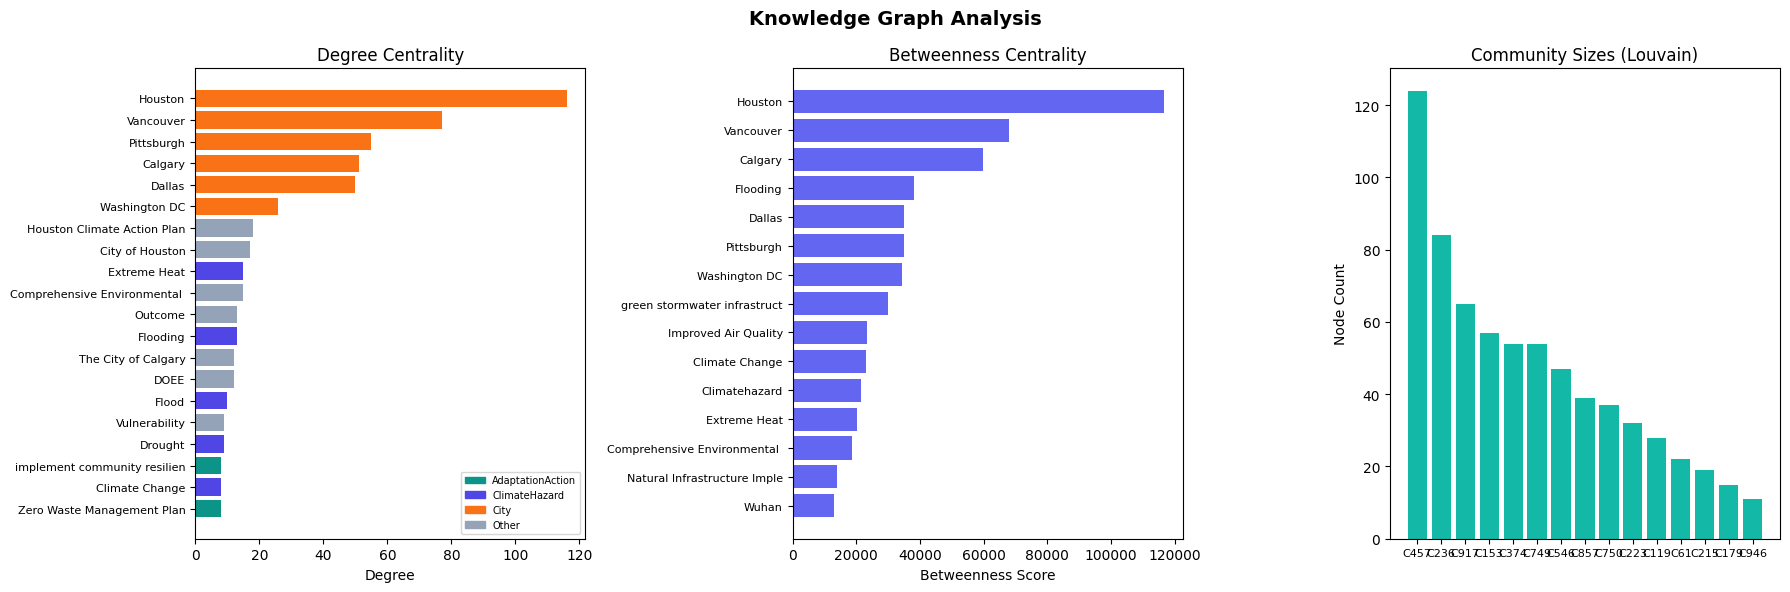


Saved → ./data/graph_analysis.png

=== Hazards shared across multiple cities ===
                  hazard  city_count                                                                                                          cities
                Flooding          10 [Ningbo, Wuhan, Washington DC, Vancouver, Pittsburgh, Houston, Greater Houston, Dallas, Calgary, Jiaozhou City]
          Climate Change           7                                         [Hefei, Washington DC, Vancouver, Pittsburgh, Houston, Dallas, Calgary]
            Extreme Heat           6                                        [Washington DC, Vancouver, Pittsburgh, Houston, Greater Houston, Dallas]
           Climatehazard           6                                                [Washington DC, Vancouver, Pittsburgh, Houston, Dallas, Calgary]
                  Floods           4                                                                           [Vancouver, Houston, Dallas, Calgary]
           Air Pollution

In [ ]:
from neo4j import GraphDatabase
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

kg = Neo4jKG(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, "kg200city")


try:
    kg.run_write("CALL gds.graph.drop('climate_graph', false)")
except:
    pass

kg.run_write("""
CALL gds.graph.project(
    'climate_graph',
    ['City', 'ClimateHazard', 'AdaptationAction', 'Outcome', 
     'Actor', 'Policy', 'Vulnerability', 'Mechanism'],
    {
        EXPERIENCES:    {orientation: 'UNDIRECTED'},
        ADDRESSES:      {orientation: 'UNDIRECTED'},
        PRODUCES:       {orientation: 'UNDIRECTED'},
        IMPLEMENTS:     {orientation: 'UNDIRECTED'},
        MANDATES:       {orientation: 'UNDIRECTED'},
        LOCATED_IN:     {orientation: 'UNDIRECTED'},
        WORSENS:        {orientation: 'UNDIRECTED'},
        ISSUED_BY:      {orientation: 'UNDIRECTED'},
        PARTICIPATES_IN:{orientation: 'UNDIRECTED'},
        COORDINATES_WITH:{orientation: 'UNDIRECTED'}
    }
)
""")
print("Graph projected to GDS memory")

# Degree Centrality 
print("\n=== Degree Centrality (Top 20) ===")
result = kg.run("""
CALL gds.degree.stream('climate_graph')
YIELD nodeId, score
WITH gds.util.asNode(nodeId) AS node, score
WHERE score > 0
RETURN 
    labels(node)[0] AS type,
    coalesce(node.name, node.action_name, node.policy_name, node.indicator_name) AS name,
    score AS degree
ORDER BY degree DESC
LIMIT 20
""")
df_degree = pd.DataFrame(result)
print(df_degree.to_string(index=False))

# Betweenness Centrality 
print("\n=== Betweenness Centrality (Top 15) ===")
result = kg.run("""
CALL gds.betweenness.stream('climate_graph')
YIELD nodeId, score
WITH gds.util.asNode(nodeId) AS node, score
WHERE score > 0
RETURN
    labels(node)[0] AS type,
    coalesce(node.name, node.action_name, node.policy_name, node.indicator_name) AS name,
    round(score, 2) AS betweenness
ORDER BY betweenness DESC
LIMIT 15
""")
df_between = pd.DataFrame(result)
print(df_between.to_string(index=False))

# PageRank 
print("\n=== PageRank (Top 15) ===")
result = kg.run("""
CALL gds.pageRank.stream('climate_graph', {
    dampingFactor: 0.85,
    maxIterations: 20
})
YIELD nodeId, score
WITH gds.util.asNode(nodeId) AS node, score
RETURN
    labels(node)[0] AS type,
    coalesce(node.name, node.action_name, node.policy_name, node.indicator_name) AS name,
    round(score, 4) AS pagerank
ORDER BY pagerank DESC
LIMIT 15
""")
df_pagerank = pd.DataFrame(result)
print(df_pagerank.to_string(index=False))

# Louvain Community Detection 
print("\n=== Louvain Community Detection ===")
kg.run_write("""
CALL gds.louvain.write('climate_graph', {
    writeProperty: 'community'
})
""")

result = kg.run("""
MATCH (n)
WHERE n.community IS NOT NULL
RETURN 
    n.community AS community,
    count(n) AS size,
    collect(distinct labels(n)[0])[..5] AS node_types
ORDER BY size DESC
LIMIT 15
""")
df_community = pd.DataFrame(result)
print(df_community.to_string(index=False))

print("\nTop nodes per community:")
result = kg.run("""
MATCH (n)
WHERE n.community IS NOT NULL
WITH n.community AS comm, 
     collect({
         name: coalesce(n.name, n.action_name, n.policy_name),
         type: labels(n)[0]
     })[..4] AS nodes,
     count(n) AS size
ORDER BY size DESC
LIMIT 8
RETURN comm, size, nodes
""")
for row in result:
    names = [f"{n['type']}:{n['name']}" for n in row['nodes']]
    print(f"  Community {row['comm']} (size={row['size']}): {', '.join(names)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Knowledge Graph Analysis', fontsize=14, fontweight='bold')

# Degree centrality bar chart
colors_degree = ['#0D9488' if t == 'AdaptationAction' 
                 else '#4F46E5' if t == 'ClimateHazard'
                 else '#F97316' if t == 'City'
                 else '#94A3B8' for t in df_degree['type']]
axes[0].barh(range(len(df_degree)), df_degree['degree'], color=colors_degree)
axes[0].set_yticks(range(len(df_degree)))
axes[0].set_yticklabels([str(n)[:28] for n in df_degree['name']], fontsize=8)
axes[0].set_xlabel('Degree')
axes[0].set_title('Degree Centrality')
axes[0].invert_yaxis()
patches = [
    mpatches.Patch(color='#0D9488', label='AdaptationAction'),
    mpatches.Patch(color='#4F46E5', label='ClimateHazard'),
    mpatches.Patch(color='#F97316', label='City'),
    mpatches.Patch(color='#94A3B8', label='Other'),
]
axes[0].legend(handles=patches, fontsize=7)

axes[1].barh(range(len(df_between)), df_between['betweenness'], color='#6366F1')
axes[1].set_yticks(range(len(df_between)))
axes[1].set_yticklabels([str(n)[:28] for n in df_between['name']], fontsize=8)
axes[1].set_xlabel('Betweenness Score')
axes[1].set_title('Betweenness Centrality')
axes[1].invert_yaxis()

axes[2].bar(range(len(df_community)), df_community['size'], color='#14B8A6')
axes[2].set_xticks(range(len(df_community)))
axes[2].set_xticklabels([f"C{r}" for r in df_community['community']], fontsize=8)
axes[2].set_ylabel('Node Count')
axes[2].set_title('Community Sizes (Louvain)')

plt.tight_layout()
plt.savefig('./data/graph_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved → ./data/graph_analysis.png")

print("\n=== Hazards shared across multiple cities ===")
result = kg.run("""
MATCH (c:City)-[:EXPERIENCES]->(h:ClimateHazard)
WITH h, collect(distinct c.name) AS cities, count(distinct c) AS city_count
WHERE city_count > 1
RETURN h.name AS hazard, city_count, cities
ORDER BY city_count DESC
LIMIT 15
""")
df_shared = pd.DataFrame(result)
print(df_shared.to_string(index=False))

kg.close()
print("\nGraph analysis complete.")

In [5]:
kg = Neo4jKG(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, "kg200city")

result = kg.run("""
MATCH (n)
WHERE n.community IS NOT NULL
WITH n.community AS comm, count(n) AS size
ORDER BY size DESC
LIMIT 5
WITH collect(comm) AS top_comms
UNWIND top_comms AS comm
MATCH (n)
WHERE n.community = comm
RETURN comm, 
       labels(n)[0] AS type,
       coalesce(n.name, n.action_name, n.policy_name) AS name
ORDER BY comm, type
LIMIT 60
""")
for row in result:
    print(f"[C{row['comm']}] {row['type']:20s} {row['name']}")

[C153] Actor                DOEE
[C153] Actor                Serve DC
[C153] AdaptationAction     Resilient Design Guidelines
[C153] AdaptationAction     Establish community resilience hubs
[C153] AdaptationAction     Evaluate the public housing portfolio for vulnerability to extreme heat and flooding
[C153] AdaptationAction     Increase combined sewer and separate stormwater system capacity
[C153] AdaptationAction     Comprehensive Extreme Heat Management Strategy
[C153] AdaptationAction     Building Community Heat Stress Preparedness and Response Capabilities
[C153] AdaptationAction     Incentives and Financing to Mitigate the UHI Effect
[C153] AdaptationAction     Stormwater Retention Credit Trading Program
[C153] AdaptationAction     Flood model
[C153] AdaptationAction     Multifamily Resilience and Solar Assessment Tool
[C153] AdaptationAction     RiverSmart program
[C153] AdaptationAction     District Stormwater Retention Credit (SRC) Trading Program
[C153] AdaptationAction     D

In [7]:
result = kg.run("""
MATCH (n)
WHERE n.community IS NOT NULL
WITH n.community AS comm, count(n) AS total
ORDER BY total DESC
LIMIT 5
WITH collect({comm: comm, total: total}) AS top5
UNWIND top5 AS item

MATCH (n {community: item.comm})
WITH item.comm AS comm, item.total AS total,
     collect(CASE WHEN labels(n)[0] = 'ClimateHazard' THEN n.name END)[..4] AS hazards,
     collect(CASE WHEN labels(n)[0] = 'AdaptationAction' THEN n.action_name END)[..4] AS actions,
     collect(CASE WHEN labels(n)[0] = 'City' THEN n.name END) AS cities

RETURN comm, total, 
       [x IN cities WHERE x IS NOT NULL] AS cities,
       [x IN hazards WHERE x IS NOT NULL] AS hazards,
       [x IN actions WHERE x IS NOT NULL] AS actions
ORDER BY total DESC
""")

print("=== Community Themes ===")
for row in result:
    print(f"\nCommunity {row['comm']} ({row['total']} nodes)")
    print(f"  Cities  : {row['cities']}")
    print(f"  Hazards : {row['hazards']}")
    print(f"  Actions : {row['actions']}")


=== Community Themes ===

Community 457 (124 nodes)
  Cities  : ['Houston']
  Hazards : ['Hurricane Harvey', 'Income Inequality', 'Heat Index Increase', 'Severe Weather']
  Actions : ['Build Houston Forward', 'Complete Communities initiative', 'Neighborhood Ready training program', 'Houston’s Incentives for Green Development']

Community 236 (84 nodes)
  Cities  : ['Vancouver']
  Hazards : ['Heat Waves', 'Extreme Rainfall', 'Sea Level Rise', 'Heat Dome']
  Actions : ['Resilient Neighbourhoods Program', 'Civic Water Use Reduction Projects', 'Groundwater Strategy', 'Resilient Neighbourhoods Toolkit']

Community 917 (65 nodes)
  Cities  : ['Calgary']
  Hazards : ['Wildfires', 'Floods', 'Transportation-Related Emissions', 'Severe Weather Events']
  Actions : ['Natural Infrastructure Valuation Toolkit', 'Calgary Dollars', 'Point Trotter Autonomous Systems Drone Flight Area', 'Advance Equity in Organizations with a Multi-Sectoral Community of Practice']

Community 153 (57 nodes)
  Cities  : 

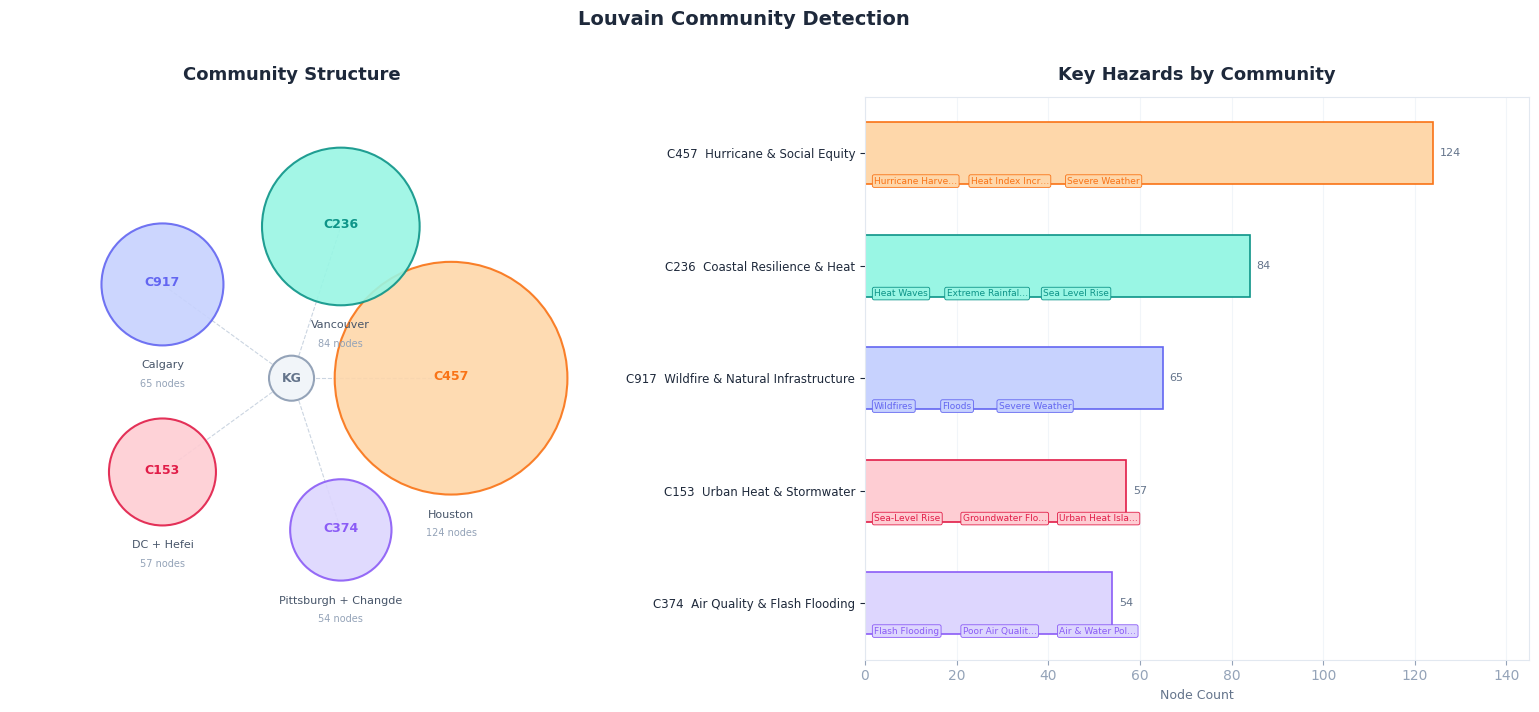

Saved → ./data/community_analysis.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

communities = [
    {
        "id": "C457", "size": 124,
        "city": "Houston",
        "theme": "Hurricane & Social Equity",
        "hazards": ["Hurricane Harvey", "Heat Index Increase", "Severe Weather", "Income Inequality"],
        "color": "#F97316"
    },
    {
        "id": "C236", "size": 84,
        "city": "Vancouver",
        "theme": "Coastal Resilience & Heat",
        "hazards": ["Heat Waves", "Extreme Rainfall", "Sea Level Rise", "Heat Dome"],
        "color": "#0D9488"
    },
    {
        "id": "C917", "size": 65,
        "city": "Calgary",
        "theme": "Wildfire & Natural Infrastructure",
        "hazards": ["Wildfires", "Floods", "Severe Weather", "Emissions"],
        "color": "#6366F1"
    },
    {
        "id": "C153", "size": 57,
        "city": "DC + Hefei",
        "theme": "Urban Heat & Stormwater",
        "hazards": ["Sea-Level Rise", "Groundwater Flooding", "Urban Heat Island", "Climate Change"],
        "color": "#E11D48"
    },
    {
        "id": "C374", "size": 54,
        "city": "Pittsburgh + Changde",
        "theme": "Air Quality & Flash Flooding",
        "hazards": ["Flash Flooding", "Poor Air Quality", "Air & Water Pollution", "Climate Hazards"],
        "color": "#8B5CF6"
    },
]

# 浅色版本
light_colors = {
    "#F97316": "#FED7AA",
    "#0D9488": "#99F6E4",
    "#6366F1": "#C7D2FE",
    "#E11D48": "#FECDD3",
    "#8B5CF6": "#DDD6FE",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')

# ── LEFT: bubble chart ────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Community Structure', color='#1E293B', fontsize=13,
             fontweight='bold', pad=12)

angles = np.linspace(0, 2 * np.pi, len(communities), endpoint=False)
positions = [(0.85 * np.cos(a), 0.85 * np.sin(a)) for a in angles]

for i, (comm, pos) in enumerate(zip(communities, positions)):
    radius = comm["size"] / 200
    # light fill circle
    circle = plt.Circle(pos, radius,
                        color=light_colors[comm["color"]],
                        ec=comm["color"], linewidth=1.5,
                        alpha=0.9, zorder=3)
    ax.add_patch(circle)
    ax.text(pos[0], pos[1] + 0.01, comm["id"],
            ha='center', va='center', fontsize=9,
            fontweight='bold', color=comm["color"], zorder=4)
    ax.text(pos[0], pos[1] - radius - 0.08, comm["city"],
            ha='center', va='top', fontsize=8,
            color='#475569', zorder=4)
    ax.text(pos[0], pos[1] - radius - 0.18,
            f"{comm['size']} nodes",
            ha='center', va='top', fontsize=7,
            color='#94A3B8', zorder=4)
    ax.plot([0, pos[0]], [0, pos[1]],
            color='#CBD5E1', linewidth=0.8,
            zorder=1, linestyle='--')

# center node
center = plt.Circle((0, 0), 0.12, color='#F1F5F9',
                     ec='#94A3B8', linewidth=1.5, zorder=3)
ax.add_patch(center)
ax.text(0, 0, 'KG', ha='center', va='center',
        fontsize=9, color='#64748B', fontweight='bold', zorder=4)

# ── RIGHT: horizontal bar ─────────────────────────────────────────
ax = axes[1]
ax.set_facecolor('white')
ax.set_title('Key Hazards by Community', color='#1E293B',
             fontsize=13, fontweight='bold', pad=12)

bar_height = 0.55

for i, comm in enumerate(communities):
    y = len(communities) - 1 - i
    ax.barh(y, comm["size"], height=bar_height,
            color=light_colors[comm["color"]],
            edgecolor=comm["color"], linewidth=1.2)
    ax.text(comm["size"] + 1.5, y, f"{comm['size']}",
            va='center', color='#64748B', fontsize=8)
    tag_x = 2
    for hazard in comm["hazards"][:3]:
        short = hazard[:15] + "…" if len(hazard) > 15 else hazard
        ax.text(tag_x, y - 0.27, short,
                fontsize=6.5, color=comm["color"],
                bbox=dict(boxstyle='round,pad=0.2',
                          facecolor=light_colors[comm["color"]],
                          edgecolor=comm["color"],
                          linewidth=0.6))
        tag_x += len(short) * 0.88 + 7

ax.set_yticks(range(len(communities)))
ax.set_yticklabels(
    [f"{c['id']}  {c['theme']}" for c in reversed(communities)],
    color='#1E293B', fontsize=8.5
)
ax.set_xlabel('Node Count', color='#64748B', fontsize=9)
ax.tick_params(axis='x', colors='#94A3B8')
ax.tick_params(axis='y', colors='#1E293B')
for spine in ax.spines.values():
    spine.set_edgecolor('#E2E8F0')
ax.set_xlim(0, 145)
ax.grid(axis='x', color='#F1F5F9', linewidth=0.8)
ax.set_axisbelow(True)

plt.suptitle('Louvain Community Detection',
             color='#1E293B', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./data/community_analysis.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved → ./data/community_analysis.png")

In [11]:
EMBEDDING_MODEL = "text-embedding-3-small"

In [ ]:
def neo4j_json_serializer(obj):
    if hasattr(obj, 'isoformat'):
        return obj.isoformat()
    if hasattr(obj, '__str__'):
        return str(obj)
    raise TypeError(f'Object of type {obj.__class__.__name__} is not JSON serializable')

with open('./data/qa_results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2, default=neo4j_json_serializer)
print("\nSaved → ./data/qa_results.json")

In [ ]:
import json
from openai import OpenAI
from neo4j import GraphDatabase

EMBEDDING_MODEL = "text-embedding-3-small"
MODEL_NAME = "gpt-4o-mini"

client = OpenAI(api_key=OPENAI_API_KEY)
kg = Neo4jKG(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, "kg200city")


def embed(text: str) -> list:
    response = client.embeddings.create(
        model=EMBEDDING_MODEL,
        input=text
    )
    return response.data[0].embedding

def build_vector_index():
    print("Building vector embeddings...")

    actions = kg.run("""
        MATCH (a:AdaptationAction)
        WHERE a.embedding IS NULL
        RETURN elementId(a) AS eid, 
               coalesce(a.action_name, '') + ' ' + 
               coalesce(a.adaptation_type, '') + ' ' +
               coalesce(a.co_benefits, '') AS text
    """)
    for row in tqdm(actions, desc="Embedding actions"):
        if not row['text'].strip():
            continue
        vec = embed(row['text'])
        kg.run_write("""
            MATCH (a:AdaptationAction)
            WHERE elementId(a) = $eid
            SET a.embedding = $vec
        """, {"eid": row['eid'], "vec": vec})

    hazards = kg.run("""
        MATCH (h:ClimateHazard)
        WHERE h.embedding IS NULL
        RETURN elementId(h) AS eid,
               coalesce(h.name, '') + ' ' +
               coalesce(h.hazard_type, '') AS text
    """)
    for row in tqdm(hazards, desc="Embedding hazards"):
        if not row['text'].strip():
            continue
        vec = embed(row['text'])
        kg.run_write("""
            MATCH (h:ClimateHazard)
            WHERE elementId(h) = $eid
            SET h.embedding = $vec
        """, {"eid": row['eid'], "vec": vec})

    try:
        kg.run_write("""
            CREATE VECTOR INDEX node_embedding IF NOT EXISTS
            FOR (a:AdaptationAction) ON a.embedding
            OPTIONS {indexConfig: {
                `vector.dimensions`: 1536,
                `vector.similarity_function`: 'cosine'
            }}
        """)
        kg.run_write("""
            CREATE VECTOR INDEX hazard_embedding IF NOT EXISTS
            FOR (h:ClimateHazard) ON h.embedding
            OPTIONS {indexConfig: {
                `vector.dimensions`: 1536,
                `vector.similarity_function`: 'cosine'
            }}
        """)
    except Exception as e:
        print(f"Index already exists: {e}")

    print("Vector index ready.")

# build_vector_index()

r = kg.run("MATCH (a:AdaptationAction) WHERE a.embedding IS NOT NULL RETURN count(a) AS cnt")
print(f"Actions with embedding: {r[0]['cnt']}")
r = kg.run("MATCH (h:ClimateHazard) WHERE h.embedding IS NOT NULL RETURN count(h) AS cnt")
print(f"Hazards with embedding: {r[0]['cnt']}")

def vector_retrieve(query: str, top_k: int = 5) -> dict:
    q_vec = embed(query)

    actions = kg.run("""
        CALL db.index.vector.queryNodes('node_embedding', $k, $vec)
        YIELD node, score
        MATCH (node)-[:LOCATED_IN]->(c:City)
        OPTIONAL MATCH (node)-[:ADDRESSES]->(h:ClimateHazard)
        OPTIONAL MATCH (node)-[:PRODUCES]->(o:Outcome)
        RETURN 
            node.action_name AS name,
            'AdaptationAction' AS type,
            c.name AS city,
            collect(distinct h.name)[..3] AS hazards,
            collect(distinct o.name)[..3] AS outcomes,
            score
        ORDER BY score DESC
    """, {"k": top_k, "vec": q_vec})

    hazards = kg.run("""
        CALL db.index.vector.queryNodes('hazard_embedding', $k, $vec)
        YIELD node, score
        MATCH (c:City)-[:EXPERIENCES]->(node)
        OPTIONAL MATCH (a:AdaptationAction)-[:ADDRESSES]->(node)
        RETURN 
            node.name AS name,
            'ClimateHazard' AS type,
            collect(distinct c.name)[..4] AS cities,
            collect(distinct a.action_name)[..3] AS actions,
            score
        ORDER BY score DESC
    """, {"k": top_k, "vec": q_vec})

    return {"actions": actions, "hazards": hazards}


def entity_link(query: str) -> list:
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{
            "role": "user",
            "content": f"""Extract entities from this query for a climate adaptation knowledge graph.
Return JSON only with keys: cities (list), hazards (list), actions (list).
Query: {query}"""
        }],
        response_format={"type": "json_object"},
        temperature=0.0
    )
    entities = json.loads(response.choices[0].message.content)
    linked = []

    for city in entities.get("cities", []):
        result = kg.run("""
            MATCH (c:City)
            WHERE toLower(c.name) CONTAINS toLower($name)
            RETURN c.name AS name, 'City' AS type, elementId(c) AS eid
            LIMIT 3
        """, {"name": city})
        linked.extend(result)

    for hazard in entities.get("hazards", []):
        result = kg.run("""
            MATCH (h:ClimateHazard)
            WHERE toLower(h.name) CONTAINS toLower($name)
            RETURN h.name AS name, 'ClimateHazard' AS type, elementId(h) AS eid
            LIMIT 3
        """, {"name": hazard})
        linked.extend(result)

    for action in entities.get("actions", []):
        result = kg.run("""
            MATCH (a:AdaptationAction)
            WHERE toLower(a.action_name) CONTAINS toLower($name)
            RETURN a.action_name AS name, 'AdaptationAction' AS type, elementId(a) AS eid
            LIMIT 3
        """, {"name": action})
        linked.extend(result)

    return linked

def multihop_retrieve(linked_entities: list, max_hops: int = 2) -> dict:
    if not linked_entities:
        return {}

    subgraphs = {}

    for entity in linked_entities:
        eid   = entity['eid']
        name  = entity['name']
        etype = entity['type']

        if etype == 'City':
            result = kg.run("""
                MATCH (c:City)-[:EXPERIENCES]->(h:ClimateHazard)
                      <-[:ADDRESSES]-(a:AdaptationAction)-[:PRODUCES]->(o:Outcome)
                WHERE elementId(c) = $eid
                RETURN c.name AS city,
                       h.name AS hazard,
                       a.action_name AS action,
                       collect(distinct o.name)[..3] AS outcomes,
                       a.cost_usd AS cost,
                       a.status AS status
                LIMIT 10
            """, {"eid": eid})

            governance = kg.run("""
                MATCH (p:Policy)-[:MANDATES]->(a:AdaptationAction)-[:LOCATED_IN]->(c:City)
                WHERE elementId(c) = $eid
                OPTIONAL MATCH (actor:Actor)-[:IMPLEMENTS]->(a)
                RETURN p.policy_name AS policy,
                       a.action_name AS action,
                       collect(distinct actor.name)[..3] AS implementors
                LIMIT 8
            """, {"eid": eid})

            subgraphs[name] = {"causal_chains": result, "governance": governance}

        elif etype == 'ClimateHazard':
            result = kg.run("""
                MATCH (c:City)-[:EXPERIENCES]->(h:ClimateHazard)
                      <-[:ADDRESSES]-(a:AdaptationAction)
                WHERE elementId(h) = $eid
                OPTIONAL MATCH (a)-[:PRODUCES]->(o:Outcome)
                RETURN c.name AS city,
                       a.action_name AS action,
                       a.adaptation_type AS type,
                       collect(distinct o.name)[..2] AS outcomes
                LIMIT 15
            """, {"eid": eid})
            subgraphs[name] = {"city_responses": result}

        elif etype == 'AdaptationAction':
            result = kg.run("""
                MATCH (a:AdaptationAction)
                WHERE elementId(a) = $eid
                OPTIONAL MATCH (a)-[:LOCATED_IN]->(c:City)
                OPTIONAL MATCH (a)-[:ADDRESSES]->(h:ClimateHazard)
                OPTIONAL MATCH (a)-[:PRODUCES]->(o:Outcome)
                OPTIONAL MATCH (actor:Actor)-[:IMPLEMENTS]->(a)
                OPTIONAL MATCH (p:Policy)-[:MANDATES]->(a)
                OPTIONAL MATCH (a)-[:FACILITATED_BY]->(m:Mechanism)
                RETURN a.action_name AS action,
                       a.status AS status,
                       a.cost_usd AS cost,
                       c.name AS city,
                       collect(distinct h.name) AS hazards,
                       collect(distinct o.name) AS outcomes,
                       collect(distinct actor.name) AS implementors,
                       collect(distinct p.policy_name) AS policies,
                       collect(distinct m.name) AS mechanisms
            """, {"eid": eid})
            subgraphs[name] = {"action_detail": result}

    return subgraphs

def subgraph_retrieve(linked_entities: list) -> list:
    if not linked_entities:
        return []

    eids = [e['eid'] for e in linked_entities]

    result = kg.run("""
        UNWIND $eids AS eid1
        UNWIND $eids AS eid2
        WITH eid1, eid2
        WHERE eid1 < eid2
        MATCH path = shortestPath((n1)-[*1..3]-(n2))
        WHERE elementId(n1) = eid1 AND elementId(n2) = eid2
        RETURN [node in nodes(path) | 
                coalesce(node.name, node.action_name, node.policy_name)] AS node_names,
               [rel in relationships(path) | type(rel)] AS rel_types
        LIMIT 10
    """, {"eids": eids})

    return result


CYPHER_SYSTEM = """You are a Neo4j Cypher expert for an urban climate adaptation knowledge graph.

Schema:
Node types: City, ClimateHazard, AdaptationAction, Outcome, Actor, Policy, 
            Mechanism, Constraint, Vulnerability, UrbanZone, Infrastructure,
            ExposureUnit, Indicator, ResilienceState, TimePoint

Key relationships:
  (City)-[:EXPERIENCES]->(ClimateHazard)
  (ClimateHazard)<-[:ADDRESSES]-(AdaptationAction)
  (AdaptationAction)-[:PRODUCES]->(Outcome)
  (AdaptationAction)-[:LOCATED_IN]->(City)
  (Policy)-[:MANDATES]->(AdaptationAction)
  (Actor)-[:IMPLEMENTS]->(AdaptationAction)
  (Policy)-[:ISSUED_BY]->(Actor)
  (ClimateHazard)-[:WORSENS]->(Vulnerability)
  (Actor)-[:COORDINATES_WITH]->(Actor)
  (AdaptationAction)-[:FACILITATED_BY]->(Mechanism)
  (AdaptationAction)-[:HINDERED_BY]->(Constraint)

Rules:
1. Return ONLY valid Cypher. No explanation, no markdown.
2. Always LIMIT results (max 20).
3. Use OPTIONAL MATCH for non-essential relationships.
4. Use toLower() for string matching.
5. Always return node properties, not node objects.
"""

def llm_cypher_generate(query: str) -> str:
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": CYPHER_SYSTEM},
            {"role": "user", "content": f"Generate a Cypher query for: {query}"}
        ],
        temperature=0.0
    )
    cypher = response.choices[0].message.content.strip()
    cypher = cypher.replace("```cypher", "").replace("```", "").strip()
    return cypher

def safe_cypher_execute(cypher: str) -> list:
    try:
        return kg.run(cypher)
    except Exception as e:
        print(f"Cypher execution failed: {e}")
        return []


def serialize_context(
    vector_results: dict,
    graph_results: dict,
    cypher_results: list,
    subgraph_paths: list
) -> str:
    parts = []

    if vector_results.get("actions"):
        parts.append("=== Relevant Adaptation Actions (semantic search) ===")
        for r in vector_results["actions"][:5]:
            parts.append(
                f"• [{r['city']}] {r['name']}"
                f"\n  Addresses: {', '.join(r.get('hazards', []))}"
                f"\n  Outcomes: {', '.join(r.get('outcomes', []))}"
                f"\n  Similarity: {r.get('score', 0):.3f}"
            )

    if vector_results.get("hazards"):
        parts.append("\n=== Related Climate Hazards (semantic search) ===")
        for r in vector_results["hazards"][:3]:
            parts.append(
                f"• {r['name']} — experienced by: {', '.join(r.get('cities', []))}"
                f"\n  Addressed by: {', '.join(r.get('actions', []))}"
            )

    if graph_results:
        parts.append("\n=== Graph Traversal Results ===")
        for entity_name, data in graph_results.items():
            parts.append(f"\nSubgraph around [{entity_name}]:")
            if "causal_chains" in data:
                for chain in data["causal_chains"][:5]:
                    parts.append(
                        f"  {chain.get('city')} → {chain.get('hazard')} "
                        f"→ {chain.get('action')} → {chain.get('outcomes', [])}"
                    )
            if "city_responses" in data:
                for r in data["city_responses"][:5]:
                    parts.append(
                        f"  {r.get('city')}: {r.get('action')} "
                        f"(type: {r.get('type')}) → {r.get('outcomes', [])}"
                    )
            if "action_detail" in data and data["action_detail"]:
                d = data["action_detail"][0]
                parts.append(
                    f"  Action: {d.get('action')}\n"
                    f"  City: {d.get('city')} | Status: {d.get('status')}\n"
                    f"  Hazards addressed: {d.get('hazards', [])}\n"
                    f"  Outcomes: {d.get('outcomes', [])}\n"
                    f"  Implemented by: {d.get('implementors', [])}"
                )

    if subgraph_paths:
        parts.append("\n=== Connecting Paths in Graph ===")
        for path in subgraph_paths[:5]:
            nodes = path.get("node_names", [])
            rels  = path.get("rel_types", [])
            path_str = ""
            for i, node in enumerate(nodes):
                path_str += str(node)
                if i < len(rels):
                    path_str += f" -[{rels[i]}]→ "
            parts.append(f"  {path_str}")

    if cypher_results:
        parts.append("\n=== Structured Query Results ===")
        for row in cypher_results[:8]:
            parts.append(f"  {dict(row)}")

    return "\n".join(parts)

ANSWER_SYSTEM = """You are an expert on urban climate adaptation policy.
Answer the user's question based ONLY on the provided knowledge graph context.

Rules:
1. Ground every claim in the retrieved context — do not hallucinate.
2. Cite specific cities, actions, or policies from the context.
3. If the context is insufficient, say so explicitly.
4. Structure your answer clearly with key findings first.
5. Keep answers concise (150-250 words).
"""

def generate_answer(query: str, context: str) -> str:
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": ANSWER_SYSTEM},
            {"role": "user", "content":
             f"Context from knowledge graph:\n{context}\n\nQuestion: {query}"}
        ],
        temperature=0.2,
        max_tokens=500
    )
    return response.choices[0].message.content


def neo4j_json_serializer(obj):
    if hasattr(obj, 'isoformat'):
        return obj.isoformat()
    if hasattr(obj, '__str__'):
        return str(obj)
    raise TypeError(f'Object of type {obj.__class__.__name__} is not JSON serializable')

def qa_pipeline(query: str, verbose: bool = True) -> dict:
    if verbose:
        print(f"\n{'='*60}")
        print(f"Query: {query}")
        print('='*60)

    if verbose: print("\n[1] Vector retrieval...")
    vector_results = vector_retrieve(query, top_k=5)

    if verbose: print("[2] Entity linking...")
    linked = entity_link(query)
    if verbose: print(f"    Linked: {[e['name'] for e in linked]}")

    if verbose: print("[3] Multi-hop graph traversal...")
    graph_results = multihop_retrieve(linked, max_hops=2)

    if verbose: print("[4] Subgraph path extraction...")
    subgraph_paths = subgraph_retrieve(linked)

    if verbose: print("[5] LLM Cypher generation...")
    cypher = llm_cypher_generate(query)
    if verbose: print(f"    Generated: {cypher[:100]}...")
    cypher_results = safe_cypher_execute(cypher)

    if verbose: print("[6] Serializing context...")
    context = serialize_context(
        vector_results, graph_results, cypher_results, subgraph_paths
    )

    if verbose: print("[7] Generating answer...")
    answer = generate_answer(query, context)

    if verbose:
        print(f"\n{'─'*60}")
        print("ANSWER:")
        print(answer)
        print(f"{'─'*60}")

    return {
        "query":           query,
        "linked_entities": [dict(e) for e in linked],
        "cypher":          cypher,
        "cypher_results":  [dict(r) for r in cypher_results],
        "context":         context,
        "answer":          answer,
        "vector_hits":     len(vector_results.get("actions", [])),
        "graph_hits":      sum(len(v) for v in graph_results.values()),
    }


test_queries = [
    "What adaptation strategies does Houston use to address flooding?",
    "Which cities share similar approaches to extreme heat management?",
    "What are the outcomes of green infrastructure interventions across North American cities?",
    "How do Vancouver and Calgary differ in their climate resilience policies?",
]

results = []
for q in test_queries:
    r = qa_pipeline(q, verbose=True)
    results.append(r)
    time.sleep(1)

with open('./data/qa_results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2, default=neo4j_json_serializer)
print("\nSaved → ./data/qa_results.json")

Actions with embedding: 642
Hazards with embedding: 205

Query: What adaptation strategies does Houston use to address flooding?

[1] Vector retrieval...
[2] Entity linking...
    Linked: ['Houston', 'Greater Houston', 'Flash Flooding', 'Flooding', 'Extreme Heat And Flooding']
[3] Multi-hop graph traversal...
[4] Subgraph path extraction...
[5] LLM Cypher generation...


Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `type` does not exist in database `kg200city`. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=83, offset=82>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 82, 'line': 1, 'column': 83}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (city:City {name: 'Houston'})-[:EXPERIENCES]->(climateHazard:ClimateHazard {type: 'Flooding'})<-[:ADDRESSES]-(adaptationAction:AdaptationAction)\nRETURN DISTINCT adaptationAction {.*}\nLIMIT 20"


    Generated: MATCH (city:City {name: 'Houston'})-[:EXPERIENCES]->(climateHazard:ClimateHazard {type: 'Flooding'})...
[6] Serializing context...
[7] Generating answer...

────────────────────────────────────────────────────────────
ANSWER:
Houston employs several adaptation strategies to address flooding, particularly in the wake of Hurricane Harvey. Key actions include:

1. **Smart City Houston Program**: This initiative aims to enhance urban resilience through technology and data-driven solutions, although specific outcomes are not detailed in the context.

2. **Flood and Climate Risk Education Initiative**: This program focuses on community engagement to educate residents about flooding risks and preparedness, which is crucial for enhancing local resilience.

3. **Natural Infrastructure**: Houston utilizes natural infrastructure solutions, such as the implementation of "Lily Pads," which serve as safe places of refuge and foster community networks for support and mutual aid during 

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `description` does not exist in database `kg200city`. Verify that the spelling is correct.', position=<SummaryInputPosition line=4, column=76, offset=283>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 283, 'line': 4, 'column': 76}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (city:City)-[:LOCATED_IN]->(adaptationAction:AdaptationAction)-[:PRODUCES]->(outcome:Outcome)\nWHERE toLower(city.name) CONTAINS 'north america'\nAND adaptationAction.name CONTAINS 'green infrastructure'\nRETURN city.name AS cityName, adaptationAction.name AS actionName, outcome.description AS outc

    Generated: MATCH (city:City)-[:LOCATED_IN]->(adaptationAction:AdaptationAction)-[:PRODUCES]->(outcome:Outcome)
...
[6] Serializing context...
[7] Generating answer...

────────────────────────────────────────────────────────────
ANSWER:
The context provided does not specify the outcomes of green infrastructure interventions across North American cities. However, it does mention that Houston has experienced issues related to Green Stormwater Infrastructure, indicating that the city is addressing these challenges through such interventions. 

In addition, Calgary is noted for its experience with Natural Infrastructure, while Pittsburgh is recognized for its focus on Urban Resilience. These references suggest that cities are actively engaging with various forms of infrastructure to enhance their resilience to climate hazards, but specific outcomes or results from these interventions are not detailed in the context provided.

For a comprehensive understanding of the outcomes of green i

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `title` does not exist in database `kg200city`. Verify that the spelling is correct.', position=<SummaryInputPosition line=6, column=32, offset=261>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 261, 'line': 6, 'column': 32}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (city:City)\nWHERE toLower(city.name) IN ['vancouver', 'calgary']\nOPTIONAL MATCH (policy:Policy)-[:ISSUED_BY]->(actor:Actor)\nOPTIONAL MATCH (policy)-[:MANDATES]->(adaptationAction:AdaptationAction)\nRETURN city.name AS city, \n       collect(DISTINCT policy.title) AS policies, \n       collect(DISTINCT

    Generated: MATCH (city:City)
WHERE toLower(city.name) IN ['vancouver', 'calgary']
OPTIONAL MATCH (policy:Policy...
[6] Serializing context...
[7] Generating answer...

────────────────────────────────────────────────────────────
ANSWER:
Key Findings:

1. **Flooding Initiatives**: Both Vancouver and Calgary have implemented flood-related initiatives. Vancouver focuses on a flood and climate risk education initiative that emphasizes community engagement. Calgary has a similar initiative aimed at community engagement as well.

2. **Natural Infrastructure**: Calgary has adopted natural infrastructure solutions, such as "Lily Pads," which serve as safe places of refuge and foster community networks for support and mutual aid. This indicates a proactive approach to integrating community support systems into their resilience strategies.

3. **Immediate Relief Measures**: Vancouver has taken steps to address extreme weather through the implementation of temporary modular housing, providing

## reasoning version 2 (with full nodes vector)

In [ ]:
import json
import time
from tqdm import tqdm
from openai import OpenAI
from neo4j import GraphDatabase


# Neo4j connection

class Neo4jKG:
    def __init__(self, uri, user, password, database):
        self.driver   = GraphDatabase.driver(uri, auth=(user, password))
        self.database = database

    def run(self, query, params=None):
        with self.driver.session(database=self.database) as session:
            result = session.run(query, params or {})
            return [dict(r) for r in result]

    def run_write(self, query, params=None):
        with self.driver.session(database=self.database) as session:
            session.execute_write(lambda tx: tx.run(query, params or {}))

    def close(self):
        self.driver.close()


client = OpenAI(api_key=OPENAI_API_KEY)
kg     = Neo4jKG(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, "kg200city")



#Vector index creation

def embed(text: str) -> list:
    response = client.embeddings.create(
        model=EMBEDDING_MODEL,
        input=text
    )
    return response.data[0].embedding


def build_vector_index():
    print("Building vector embeddings for all node types...")

    # --- AdaptationAction ---
    actions = kg.run("""
        MATCH (a:AdaptationAction)
        WHERE a.embedding IS NULL
        RETURN elementId(a) AS eid,
               coalesce(a.action_name, '') + ' ' +
               coalesce(a.adaptation_type, '') + ' ' +
               coalesce(a.co_benefits, '') AS text
    """)
    for row in tqdm(actions, desc="Embedding AdaptationAction"):
        if not row['text'].strip():
            continue
        vec = embed(row['text'])
        kg.run_write("""
            MATCH (a:AdaptationAction) WHERE elementId(a) = $eid
            SET a.embedding = $vec
        """, {"eid": row['eid'], "vec": vec})

    # --- ClimateHazard ---
    hazards = kg.run("""
        MATCH (h:ClimateHazard)
        WHERE h.embedding IS NULL
        RETURN elementId(h) AS eid,
               coalesce(h.name, '') + ' ' +
               coalesce(h.hazard_type, '') AS text
    """)
    for row in tqdm(hazards, desc="Embedding ClimateHazard"):
        if not row['text'].strip():
            continue
        vec = embed(row['text'])
        kg.run_write("""
            MATCH (h:ClimateHazard) WHERE elementId(h) = $eid
            SET h.embedding = $vec
        """, {"eid": row['eid'], "vec": vec})

    # --- Policy ---
    policies = kg.run("""
        MATCH (p:Policy)
        WHERE p.embedding IS NULL
        RETURN elementId(p) AS eid,
               coalesce(p.policy_name, '') + ' ' +
               coalesce(p.policy_type, '') + ' ' +
               coalesce(p.level, '') AS text
    """)
    for row in tqdm(policies, desc="Embedding Policy"):
        if not row['text'].strip():
            continue
        vec = embed(row['text'])
        kg.run_write("""
            MATCH (p:Policy) WHERE elementId(p) = $eid
            SET p.embedding = $vec
        """, {"eid": row['eid'], "vec": vec})

    # --- Actor ---
    actors = kg.run("""
        MATCH (a:Actor)
        WHERE a.embedding IS NULL
        RETURN elementId(a) AS eid,
               coalesce(a.name, '') + ' ' +
               coalesce(a.sector, '') + ' ' +
               coalesce(a.role, '') AS text
    """)
    for row in tqdm(actors, desc="Embedding Actor"):
        if not row['text'].strip():
            continue
        vec = embed(row['text'])
        kg.run_write("""
            MATCH (a:Actor) WHERE elementId(a) = $eid
            SET a.embedding = $vec
        """, {"eid": row['eid'], "vec": vec})

    # --- Outcome ---
    outcomes = kg.run("""
        MATCH (o:Outcome)
        WHERE o.embedding IS NULL
        RETURN elementId(o) AS eid,
               coalesce(o.name, '') + ' ' +
               coalesce(o.outcome_type, '') AS text
    """)
    for row in tqdm(outcomes, desc="Embedding Outcome"):
        if not row['text'].strip():
            continue
        vec = embed(row['text'])
        kg.run_write("""
            MATCH (o:Outcome) WHERE elementId(o) = $eid
            SET o.embedding = $vec
        """, {"eid": row['eid'], "vec": vec})

    # vector
    index_configs = [
        ("node_embedding",    "AdaptationAction", "embedding"),
        ("hazard_embedding",  "ClimateHazard",    "embedding"),
        ("policy_embedding",  "Policy",           "embedding"),
        ("actor_embedding",   "Actor",            "embedding"),
        ("outcome_embedding", "Outcome",          "embedding"),
    ]
    for index_name, label, prop in index_configs:
        try:
            kg.run_write(f"""
                CREATE VECTOR INDEX {index_name} IF NOT EXISTS
                FOR (n:{label}) ON n.{prop}
                OPTIONS {{indexConfig: {{
                    `vector.dimensions`: 1536,
                    `vector.similarity_function`: 'cosine'
                }}}}
            """)
            print(f"  Index [{index_name}] created.")
        except Exception as e:
            print(f"  Index [{index_name}] already exists or error: {e}")

    print("All vector indexes ready.")

# just implement once
# build_vector_index()

# validation
for label, desc in [
    ("AdaptationAction", "actions"),
    ("ClimateHazard",    "hazards"),
    ("Policy",           "policies"),
    ("Actor",            "actors"),
    ("Outcome",          "outcomes"),
]:
    r = kg.run(f"MATCH (n:{label}) WHERE n.embedding IS NOT NULL RETURN count(n) AS cnt")
    print(f"{desc} with embedding: {r[0]['cnt']}")



# Vector Retrieval (Full Node Type)

def vector_retrieve(query: str, top_k: int = 5) -> dict:
    q_vec = embed(query)

    # AdaptationAction
    actions = kg.run("""
        CALL db.index.vector.queryNodes('node_embedding', $k, $vec)
        YIELD node, score
        MATCH (node)-[:LOCATED_IN]->(c:City)
        OPTIONAL MATCH (node)-[:ADDRESSES]->(h:ClimateHazard)
        OPTIONAL MATCH (node)-[:PRODUCES]->(o:Outcome)
        RETURN
            node.action_name AS name,
            'AdaptationAction' AS type,
            c.name AS city,
            collect(distinct h.name)[..3] AS hazards,
            collect(distinct o.name)[..3] AS outcomes,
            score
        ORDER BY score DESC
    """, {"k": top_k, "vec": q_vec})

    # ClimateHazard
    hazards = kg.run("""
        CALL db.index.vector.queryNodes('hazard_embedding', $k, $vec)
        YIELD node, score
        MATCH (c:City)-[:EXPERIENCES]->(node)
        OPTIONAL MATCH (a:AdaptationAction)-[:ADDRESSES]->(node)
        RETURN
            node.name AS name,
            'ClimateHazard' AS type,
            collect(distinct c.name)[..4] AS cities,
            collect(distinct a.action_name)[..3] AS actions,
            score
        ORDER BY score DESC
    """, {"k": top_k, "vec": q_vec})

    # Policy
    policies = kg.run("""
        CALL db.index.vector.queryNodes('policy_embedding', $k, $vec)
        YIELD node, score
        OPTIONAL MATCH (node)-[:MANDATES]->(a:AdaptationAction)-[:LOCATED_IN]->(c:City)
        OPTIONAL MATCH (node)-[:ISSUED_BY]->(actor:Actor)
        RETURN
            node.policy_name AS name,
            'Policy' AS type,
            node.policy_type AS policy_type,
            node.level AS level,
            collect(distinct c.name)[..3] AS cities,
            collect(distinct actor.name)[..2] AS issuers,
            score
        ORDER BY score DESC
    """, {"k": top_k, "vec": q_vec})

    # Actor
    actors = kg.run("""
        CALL db.index.vector.queryNodes('actor_embedding', $k, $vec)
        YIELD node, score
        OPTIONAL MATCH (node)-[:IMPLEMENTS]->(a:AdaptationAction)-[:LOCATED_IN]->(c:City)
        RETURN
            node.name AS name,
            'Actor' AS type,
            node.sector AS sector,
            node.role AS role,
            collect(distinct c.name)[..3] AS cities,
            collect(distinct a.action_name)[..3] AS actions,
            score
        ORDER BY score DESC
    """, {"k": top_k, "vec": q_vec})

    # Outcome
    outcomes = kg.run("""
        CALL db.index.vector.queryNodes('outcome_embedding', $k, $vec)
        YIELD node, score
        OPTIONAL MATCH (a:AdaptationAction)-[:PRODUCES]->(node)
        OPTIONAL MATCH (a)-[:LOCATED_IN]->(c:City)
        RETURN
            node.name AS name,
            'Outcome' AS type,
            node.outcome_type AS outcome_type,
            collect(distinct a.action_name)[..3] AS actions,
            collect(distinct c.name)[..3] AS cities,
            score
        ORDER BY score DESC
    """, {"k": top_k, "vec": q_vec})

    return {
        "actions":  actions,
        "hazards":  hazards,
        "policies": policies,
        "actors":   actors,
        "outcomes": outcomes,
    }

#Entity Linking

def entity_link(query: str) -> list:
    #LLM extraction
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{
            "role": "user",
            "content": f"""Extract entities from this query for a climate adaptation knowledge graph.
Return JSON only with keys: cities (list), hazards (list), actions (list), policies (list), actors (list).
Query: {query}"""
        }],
        response_format={"type": "json_object"},
        temperature=0.0
    )
    entities = json.loads(response.choices[0].message.content)
    candidates = []

    # City
    for city in entities.get("cities", []):
        result = kg.run("""
            MATCH (c:City)
            WHERE toLower(c.name) CONTAINS toLower($name)
            RETURN c.name AS name, 'City' AS type, elementId(c) AS eid
            LIMIT 3
        """, {"name": city})
        candidates.extend(result)

    # ClimateHazard
    for hazard in entities.get("hazards", []):
        result = kg.run("""
            MATCH (h:ClimateHazard)
            WHERE toLower(h.name) CONTAINS toLower($name)
            RETURN h.name AS name, 'ClimateHazard' AS type, elementId(h) AS eid
            LIMIT 3
        """, {"name": hazard})
        candidates.extend(result)

    # AdaptationAction
    for action in entities.get("actions", []):
        result = kg.run("""
            MATCH (a:AdaptationAction)
            WHERE toLower(a.action_name) CONTAINS toLower($name)
            RETURN a.action_name AS name, 'AdaptationAction' AS type, elementId(a) AS eid
            LIMIT 3
        """, {"name": action})
        candidates.extend(result)

    # Policy
    for policy in entities.get("policies", []):
        result = kg.run("""
            MATCH (p:Policy)
            WHERE toLower(p.policy_name) CONTAINS toLower($name)
            RETURN p.policy_name AS name, 'Policy' AS type, elementId(p) AS eid
            LIMIT 3
        """, {"name": policy})
        candidates.extend(result)

    # Actor
    for actor in entities.get("actors", []):
        result = kg.run("""
            MATCH (a:Actor)
            WHERE toLower(a.name) CONTAINS toLower($name)
            RETURN a.name AS name, 'Actor' AS type, elementId(a) AS eid
            LIMIT 3
        """, {"name": actor})
        candidates.extend(result)

    if not candidates:
        return []

    # llm filter
    candidate_labels = [f"{e['type']}: {e['name']}" for e in candidates]
    filter_response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{
            "role": "user",
            "content": f"""Given this query: "{query}"

From the following candidate entities found in a climate adaptation knowledge graph,
select ONLY those directly relevant to answering the query.
Be strict — exclude entities that are only partially or coincidentally matching.

Candidates:
{json.dumps(candidate_labels, indent=2)}

Return JSON only with key: "selected" (list of strings, exactly as shown above)."""
        }],
        response_format={"type": "json_object"},
        temperature=0.0
    )

    selected = json.loads(
        filter_response.choices[0].message.content
    ).get("selected", [])

    linked = [
        e for e in candidates
        if f"{e['type']}: {e['name']}" in selected
    ]

    return linked



#multi-hop reasoning

def multihop_retrieve(linked_entities: list, max_hops: int = 2) -> dict:
    if not linked_entities:
        return {}

    subgraphs = {}

    for entity in linked_entities:
        eid   = entity['eid']
        name  = entity['name']
        etype = entity['type']

        if etype == 'City':
            causal = kg.run("""
                MATCH (c:City)-[:EXPERIENCES]->(h:ClimateHazard)
                      <-[:ADDRESSES]-(a:AdaptationAction)-[:PRODUCES]->(o:Outcome)
                WHERE elementId(c) = $eid
                RETURN c.name AS city,
                       h.name AS hazard,
                       a.action_name AS action,
                       collect(distinct o.name)[..3] AS outcomes,
                       a.cost_usd AS cost,
                       a.status AS status
                LIMIT 10
            """, {"eid": eid})

            governance = kg.run("""
                MATCH (p:Policy)-[:MANDATES]->(a:AdaptationAction)-[:LOCATED_IN]->(c:City)
                WHERE elementId(c) = $eid
                OPTIONAL MATCH (actor:Actor)-[:IMPLEMENTS]->(a)
                RETURN p.policy_name AS policy,
                       a.action_name AS action,
                       collect(distinct actor.name)[..3] AS implementors
                LIMIT 8
            """, {"eid": eid})

            subgraphs[name] = {"causal_chains": causal, "governance": governance}

        elif etype == 'ClimateHazard':
            result = kg.run("""
                MATCH (c:City)-[:EXPERIENCES]->(h:ClimateHazard)
                      <-[:ADDRESSES]-(a:AdaptationAction)
                WHERE elementId(h) = $eid
                OPTIONAL MATCH (a)-[:PRODUCES]->(o:Outcome)
                RETURN c.name AS city,
                       a.action_name AS action,
                       a.adaptation_type AS type,
                       collect(distinct o.name)[..2] AS outcomes
                LIMIT 15
            """, {"eid": eid})
            subgraphs[name] = {"city_responses": result}

        elif etype == 'AdaptationAction':
            result = kg.run("""
                MATCH (a:AdaptationAction)
                WHERE elementId(a) = $eid
                OPTIONAL MATCH (a)-[:LOCATED_IN]->(c:City)
                OPTIONAL MATCH (a)-[:ADDRESSES]->(h:ClimateHazard)
                OPTIONAL MATCH (a)-[:PRODUCES]->(o:Outcome)
                OPTIONAL MATCH (actor:Actor)-[:IMPLEMENTS]->(a)
                OPTIONAL MATCH (p:Policy)-[:MANDATES]->(a)
                OPTIONAL MATCH (a)-[:FACILITATED_BY]->(m:Mechanism)
                RETURN a.action_name AS action,
                       a.status AS status,
                       a.cost_usd AS cost,
                       c.name AS city,
                       collect(distinct h.name) AS hazards,
                       collect(distinct o.name) AS outcomes,
                       collect(distinct actor.name) AS implementors,
                       collect(distinct p.policy_name) AS policies,
                       collect(distinct m.name) AS mechanisms
            """, {"eid": eid})
            subgraphs[name] = {"action_detail": result}

        elif etype == 'Policy':
            result = kg.run("""
                MATCH (p:Policy)
                WHERE elementId(p) = $eid
                OPTIONAL MATCH (p)-[:MANDATES]->(a:AdaptationAction)-[:LOCATED_IN]->(c:City)
                OPTIONAL MATCH (p)-[:ISSUED_BY]->(actor:Actor)
                OPTIONAL MATCH (a)-[:ADDRESSES]->(h:ClimateHazard)
                RETURN p.policy_name AS policy,
                       p.policy_type AS policy_type,
                       p.level AS level,
                       collect(distinct c.name)[..4] AS cities,
                       collect(distinct a.action_name)[..5] AS actions,
                       collect(distinct actor.name)[..3] AS issuers,
                       collect(distinct h.name)[..3] AS hazards_addressed
                LIMIT 10
            """, {"eid": eid})
            subgraphs[name] = {"policy_detail": result}

        elif etype == 'Actor':
            result = kg.run("""
                MATCH (actor:Actor)
                WHERE elementId(actor) = $eid
                OPTIONAL MATCH (actor)-[:IMPLEMENTS]->(a:AdaptationAction)-[:LOCATED_IN]->(c:City)
                OPTIONAL MATCH (actor)-[:COORDINATES_WITH]->(other:Actor)
                RETURN actor.name AS actor,
                       actor.sector AS sector,
                       actor.role AS role,
                       collect(distinct c.name)[..4] AS cities,
                       collect(distinct a.action_name)[..5] AS actions,
                       collect(distinct other.name)[..3] AS collaborators
                LIMIT 10
            """, {"eid": eid})
            subgraphs[name] = {"actor_detail": result}

    return subgraphs


def subgraph_retrieve(linked_entities: list) -> list:
    if not linked_entities:
        return []

    eids = [e['eid'] for e in linked_entities]

    result = kg.run("""
        UNWIND $eids AS eid1
        UNWIND $eids AS eid2
        WITH eid1, eid2
        WHERE eid1 < eid2
        MATCH path = shortestPath((n1)-[*1..3]-(n2))
        WHERE elementId(n1) = eid1 AND elementId(n2) = eid2
        RETURN [node in nodes(path) |
                coalesce(node.name, node.action_name, node.policy_name)] AS node_names,
               [rel in relationships(path) | type(rel)] AS rel_types
        LIMIT 10
    """, {"eids": eids})

    return result



# LLM Cypher generation

CYPHER_SYSTEM = """You are a Neo4j Cypher expert for an urban climate adaptation knowledge graph.

Node properties (use ONLY these exact property names, no others):
- City:             name, region, country, population
- ClimateHazard:    name, hazard_type, severity
- AdaptationAction: action_name, adaptation_type, status, cost_usd, co_benefits
- Outcome:          name, outcome_type, magnitude
- Actor:            name, sector, role
- Policy:           policy_name, policy_type, level, year
- Mechanism:        name, mechanism_type
- Constraint:       name, constraint_type
- Vulnerability:    name, vulnerability_type
- UrbanZone:        name, zone_type
- Infrastructure:   name, infrastructure_type
- Indicator:        name, indicator_type, value
- ResilienceState:  name, state_type
- TimePoint:        name, year

Key relationships:
  (City)-[:EXPERIENCES]->(ClimateHazard)
  (ClimateHazard)<-[:ADDRESSES]-(AdaptationAction)
  (AdaptationAction)-[:PRODUCES]->(Outcome)
  (AdaptationAction)-[:LOCATED_IN]->(City)
  (Policy)-[:MANDATES]->(AdaptationAction)
  (Actor)-[:IMPLEMENTS]->(AdaptationAction)
  (Policy)-[:ISSUED_BY]->(Actor)
  (ClimateHazard)-[:WORSENS]->(Vulnerability)
  (Actor)-[:COORDINATES_WITH]->(Actor)
  (AdaptationAction)-[:FACILITATED_BY]->(Mechanism)
  (AdaptationAction)-[:HINDERED_BY]->(Constraint)

CRITICAL Rules:
1. Return ONLY valid Cypher. No explanation, no markdown, no backticks.
2. Always LIMIT results (max 20).
3. Use OPTIONAL MATCH for non-essential relationships.
4. Use toLower() for string matching.
5. Always return node properties, NOT node objects.
6. For ClimateHazard, always match by h.name (NOT h.type — type does not exist).
7. For AdaptationAction, always use a.action_name (NOT a.name).
8. For Policy, always use p.policy_name (NOT p.name).
9. For Actor, always use actor.name.
"""


def llm_cypher_generate(query: str) -> str:
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": CYPHER_SYSTEM},
            {"role": "user",   "content": f"Generate a Cypher query for: {query}"}
        ],
        temperature=0.0
    )
    cypher = response.choices[0].message.content.strip()
    cypher = cypher.replace("```cypher", "").replace("```", "").strip()
    return cypher


def safe_cypher_execute(cypher: str) -> list:
    try:
        return kg.run(cypher)
    except Exception as e:
        print(f"    Cypher execution failed: {e}")
        return []



# Subgraph serialization

def serialize_context(
    vector_results: dict,
    graph_results: dict,
    cypher_results: list,
    subgraph_paths: list
) -> str:
    parts = []

    # Vector results
    if vector_results.get("actions"):
        parts.append("=== Relevant Adaptation Actions (semantic search) ===")
        for r in vector_results["actions"][:5]:
            parts.append(
                f"• [{r.get('city')}] {r.get('name')}"
                f"\n  Addresses: {', '.join(r.get('hazards', []))}"
                f"\n  Outcomes: {', '.join(r.get('outcomes', []))}"
                f"\n  Similarity: {r.get('score', 0):.3f}"
            )

    if vector_results.get("hazards"):
        parts.append("\n=== Related Climate Hazards (semantic search) ===")
        for r in vector_results["hazards"][:3]:
            parts.append(
                f"• {r.get('name')} — experienced by: {', '.join(r.get('cities', []))}"
                f"\n  Addressed by: {', '.join(r.get('actions', []))}"
            )

    if vector_results.get("policies"):
        parts.append("\n=== Relevant Policies (semantic search) ===")
        for r in vector_results["policies"][:3]:
            parts.append(
                f"• {r.get('name')} [{r.get('level')}]"
                f"\n  Cities: {', '.join(r.get('cities', []))}"
                f"\n  Issued by: {', '.join(r.get('issuers', []))}"
                f"\n  Similarity: {r.get('score', 0):.3f}"
            )

    if vector_results.get("actors"):
        parts.append("\n=== Relevant Actors (semantic search) ===")
        for r in vector_results["actors"][:3]:
            parts.append(
                f"• {r.get('name')} [{r.get('sector')}]"
                f"\n  Cities active in: {', '.join(r.get('cities', []))}"
                f"\n  Actions: {', '.join(r.get('actions', []))}"
                f"\n  Similarity: {r.get('score', 0):.3f}"
            )

    if vector_results.get("outcomes"):
        parts.append("\n=== Relevant Outcomes (semantic search) ===")
        for r in vector_results["outcomes"][:3]:
            parts.append(
                f"• {r.get('name')} [{r.get('outcome_type')}]"
                f"\n  Produced by: {', '.join(r.get('actions', []))}"
                f"\n  Cities: {', '.join(r.get('cities', []))}"
                f"\n  Similarity: {r.get('score', 0):.3f}"
            )

    # Graph traversal results
    if graph_results:
        parts.append("\n=== Graph Traversal Results ===")
        for entity_name, data in graph_results.items():
            parts.append(f"\nSubgraph around [{entity_name}]:")

            if "causal_chains" in data:
                for chain in data["causal_chains"][:5]:
                    parts.append(
                        f"  {chain.get('city')} → {chain.get('hazard')} "
                        f"→ {chain.get('action')} → {chain.get('outcomes', [])}"
                    )
            if "governance" in data:
                for g in data["governance"][:3]:
                    parts.append(
                        f"  Policy: {g.get('policy')} → {g.get('action')} "
                        f"(implemented by: {g.get('implementors', [])})"
                    )
            if "city_responses" in data:
                for r in data["city_responses"][:5]:
                    parts.append(
                        f"  {r.get('city')}: {r.get('action')} "
                        f"(type: {r.get('type')}) → {r.get('outcomes', [])}"
                    )
            if "action_detail" in data and data["action_detail"]:
                d = data["action_detail"][0]
                parts.append(
                    f"  Action: {d.get('action')}\n"
                    f"  City: {d.get('city')} | Status: {d.get('status')}\n"
                    f"  Hazards addressed: {d.get('hazards', [])}\n"
                    f"  Outcomes: {d.get('outcomes', [])}\n"
                    f"  Implemented by: {d.get('implementors', [])}\n"
                    f"  Policies: {d.get('policies', [])}"
                )
            if "policy_detail" in data and data["policy_detail"]:
                d = data["policy_detail"][0]
                parts.append(
                    f"  Policy: {d.get('policy')} [{d.get('policy_type')}]\n"
                    f"  Level: {d.get('level')}\n"
                    f"  Cities: {d.get('cities', [])}\n"
                    f"  Actions mandated: {d.get('actions', [])}\n"
                    f"  Issued by: {d.get('issuers', [])}"
                )
            if "actor_detail" in data and data["actor_detail"]:
                d = data["actor_detail"][0]
                parts.append(
                    f"  Actor: {d.get('actor')} [{d.get('sector')}]\n"
                    f"  Cities: {d.get('cities', [])}\n"
                    f"  Actions: {d.get('actions', [])}\n"
                    f"  Collaborators: {d.get('collaborators', [])}"
                )

    # Connecting paths
    if subgraph_paths:
        parts.append("\n=== Connecting Paths in Graph ===")
        for path in subgraph_paths[:5]:
            nodes = path.get("node_names", [])
            rels  = path.get("rel_types", [])
            path_str = ""
            for i, node in enumerate(nodes):
                path_str += str(node)
                if i < len(rels):
                    path_str += f" -[{rels[i]}]→ "
            parts.append(f"  {path_str}")

    # Cypher results
    if cypher_results:
        parts.append("\n=== Structured Query Results ===")
        for row in cypher_results[:8]:
            parts.append(f"  {dict(row)}")

    return "\n".join(parts)


# answer generation

ANSWER_SYSTEM = """You are an expert on urban climate adaptation policy.
Answer the user's question based ONLY on the provided knowledge graph context.

Rules:
1. Ground every claim in the retrieved context — do not hallucinate.
2. Cite specific cities, actions, or policies from the context.
3. If the context is insufficient, say so explicitly.
4. Structure your answer clearly with key findings first.
5. Keep answers concise (150-250 words).
"""


def generate_answer(query: str, context: str) -> str:
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": ANSWER_SYSTEM},
            {"role": "user",   "content":
             f"Context from knowledge graph:\n{context}\n\nQuestion: {query}"}
        ],
        temperature=0.2,
        max_tokens=500
    )
    return response.choices[0].message.content

# Reasoning Path Validity 

def validate_reasoning_paths(subgraph_paths: list) -> dict:
    """验证推理路径的well-formedness，计算ill-triplet rate"""
    if not subgraph_paths:
        return {"total_paths": 0, "well_formed": 0, "ill_formed": 0, "well_formed_rate": 1.0}

    total    = len(subgraph_paths)
    ill      = 0

    for path in subgraph_paths:
        nodes = path.get("node_names", [])
        rels  = path.get("rel_types", [])
        # Path disconnected: The number of nodes and the number of relationships do not match
        if len(nodes) != len(rels) + 1:
            ill += 1
            continue
        # None
        if any(n is None for n in nodes):
            ill += 1

    well_formed = total - ill
    return {
        "total_paths":     total,
        "well_formed":     well_formed,
        "ill_formed":      ill,
        "well_formed_rate": round(well_formed / total, 3) if total > 0 else 1.0,
    }


# QA Pipeline

def neo4j_json_serializer(obj):
    if hasattr(obj, 'isoformat'):
        return obj.isoformat()
    if hasattr(obj, '__str__'):
        return str(obj)
    raise TypeError(f'Object of type {obj.__class__.__name__} is not JSON serializable')


def qa_pipeline(query: str, verbose: bool = True) -> dict:
    if verbose:
        print(f"\n{'='*60}")
        print(f"Query: {query}")
        print('='*60)

    if verbose: print("\n[1] Vector retrieval (5 node types)...")
    vector_results = vector_retrieve(query, top_k=5)

    if verbose: print("[2] Entity linking (with LLM filter)...")
    linked = entity_link(query)
    if verbose: print(f"    Linked: {[e['name'] for e in linked]}")

    if verbose: print("[3] Multi-hop graph traversal...")
    graph_results = multihop_retrieve(linked, max_hops=2)

    if verbose: print("[4] Subgraph path extraction...")
    subgraph_paths = subgraph_retrieve(linked)

    if verbose: print("[5] Validating reasoning paths...")
    path_validity = validate_reasoning_paths(subgraph_paths)
    if verbose: print(f"    Well-formed rate: {path_validity['well_formed_rate']:.3f} "
                      f"({path_validity['well_formed']}/{path_validity['total_paths']})")

    if verbose: print("[6] LLM Cypher generation...")
    cypher = llm_cypher_generate(query)
    if verbose: print(f"    Generated: {cypher[:100]}...")
    cypher_results = safe_cypher_execute(cypher)

    if verbose: print("[7] Serializing context...")
    context = serialize_context(
        vector_results, graph_results, cypher_results, subgraph_paths
    )

    if verbose: print("[8] Generating answer...")
    answer = generate_answer(query, context)

    if verbose:
        print(f"\n{'─'*60}")
        print("ANSWER:")
        print(answer)
        print(f"{'─'*60}")

    return {
        "query":            query,
        "linked_entities":  [dict(e) for e in linked],
        "cypher":           cypher,
        "cypher_results":   [dict(r) for r in cypher_results],
        "context":          context,
        "answer":           answer,
        "vector_hits": {
            k: len(v) for k, v in vector_results.items()
        },
        "graph_hits":       sum(len(v) for v in graph_results.values()),
        "path_validity":    path_validity,
    }

# test
test_queries = [
    "What adaptation strategies does Houston use to address flooding?",
    "Which cities share similar approaches to extreme heat management?",
    "What are the outcomes of green infrastructure interventions across North American cities?",
    "How do Vancouver and Calgary differ in their climate resilience policies?",
]

results = []
for q in test_queries:
    r = qa_pipeline(q, verbose=True)
    results.append(r)
    time.sleep(1)

with open('./data/qa_results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2,
              default=neo4j_json_serializer)
print("\nSaved → ./data/qa_results.json")

Building vector embeddings for all node types...


Embedding AdaptationAction: 0it [00:00, ?it/s]
Embedding ClimateHazard: 0it [00:00, ?it/s]
Embedding Outcome: 100%|██████████| 317/317 [01:47<00:00,  2.95it/s]


  Index [node_embedding] created.
  Index [hazard_embedding] created.
  Index [policy_embedding] created.
  Index [actor_embedding] created.
  Index [outcome_embedding] created.
All vector indexes ready.
actions with embedding: 642
hazards with embedding: 205
policies with embedding: 106
actors with embedding: 119
outcomes with embedding: 317

Query: What adaptation strategies does Houston use to address flooding?

[1] Vector retrieval (5 node types)...
[2] Entity linking (with LLM filter)...
    Linked: ['Houston', 'Flooding']
[3] Multi-hop graph traversal...
[4] Subgraph path extraction...
[5] Validating reasoning paths...
    Well-formed rate: 1.000 (1/1)
[6] LLM Cypher generation...
    Generated: MATCH (c:City {name: toLower("Houston")})-[:EXPERIENCES]->(h:ClimateHazard {name: toLower("flooding"...
[7] Serializing context...
[8] Generating answer...

────────────────────────────────────────────────────────────
ANSWER:
Houston employs several adaptation strategies to address floodi

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `magnitude` does not exist in database `kg200city`. Verify that the spelling is correct.', position=<SummaryInputPosition line=3, column=97, offset=252>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 252, 'line': 3, 'column': 97}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (c:City)-[:LOCATED_IN]->(a:AdaptationAction)-[:PRODUCES]->(o:Outcome)\nWHERE c.region = 'North America' AND a.adaptation_type = 'green infrastructure'\nRETURN c.name AS city, a.action_name AS adaptation_action, o.name AS outcome, o.outcome_type, o.magnitude\nLIMIT 20"


    Generated: MATCH (c:City)-[:LOCATED_IN]->(a:AdaptationAction)-[:PRODUCES]->(o:Outcome)
WHERE c.region = 'North ...
[7] Serializing context...
[8] Generating answer...

────────────────────────────────────────────────────────────
ANSWER:
Key findings on the outcomes of green infrastructure interventions across North American cities include:

1. **Improved Green Space and Reduced Urban Heat Island Effect**: In Vancouver, initiatives aimed at exploring dedicated funding streams for green infrastructure maintenance have led to enhanced green spaces and a reduction in the urban heat island effect. This highlights the dual benefits of environmental improvement and urban livability.

2. **Increased Green Stormwater Infrastructure Projects**: A notable outcome from the Green Stormwater Infrastructure Program is the completion of 100 new projects, which indicates a significant investment in managing stormwater effectively while also enhancing urban resilience.

3. **Enhanced Infrastructure 